# Demo 5 — Modelos de Visão: Distribuições de Pixels, Não Mágica

## Parte 1 — Introdução

Este notebook desmistifica modelos de visão computacional — especificamente os modelos generativos que dominam o noticiário de IA: **Veo** (Google), **DALL-E** (OpenAI), **Stable Diffusion** (Stability AI).

A narrativa de mercado apresenta esses modelos como sistemas que "veem", "imaginam" e "criam". Este notebook mostra o mecanismo real — e ele é surpreendentemente semelhante ao que vimos nos demos anteriores sobre LLMs.

---

### A analogia central

| LLM | Modelo de visão |
|---|---|
| Texto → tokens (inteiros) | Imagem → pixels (números 0–255) |
| Prever o próximo token | Aprender a distribuição de pixels |
| Atenção = token olha todos os outros | Patch attention = região olha todas as outras |
| GPT gera texto token a token | Diffusion gera imagem pixel a pixel (em etapas) |

---

### O que este notebook faz

1. Mostra que imagens são apenas matrizes de números
2. Implementa convolução manualmente para desmistificar CNNs
3. Gera um corpus 100% sintético (formas geométricas) sem nenhum download
4. Treina uma CNN simples para classificar formas
5. Visualiza o que a rede "aprendeu"
6. Implementa um processo de difusão simplificado para mostrar como DALL-E funciona
7. Conecta tudo de volta aos LLMs

### Dependências
Apenas `numpy`, `matplotlib` e `torch`. Zero downloads. Zero datasets externos.

---

> **Ambos são estimadores de distribuição condicional. Nenhum imagina. Nenhum entende.**


## Parte 2 — A Imagem Como Matriz de Números

Antes de qualquer modelo, precisamos entender o que uma imagem **realmente é** para um computador.

Um humano olha para uma foto e vê um rosto, uma paisagem, um gato. Um computador vê uma grade de números inteiros entre 0 e 255 — onde 0 é preto puro e 255 é branco puro (em escala de cinza), ou uma tripla (R, G, B) para cores.

Vamos criar uma imagem de um círculo **usando apenas operações matemáticas numpy** — sem PIL, sem OpenCV, sem bibliotecas de imagem.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Semente para reprodutibilidade
np.random.seed(42)

# Criar imagem 32x32 de um círculo branco sobre fundo preto
# Usamos apenas operações matriciais do numpy

def criar_circulo_basico(tamanho=32, cx=16, cy=16, raio=10):
    """
    Cria uma imagem binária com um círculo preenchido.
    
    Para cada pixel (i, j), verifica se a distância ao centro (cx, cy)
    é menor ou igual ao raio. Se sim, o pixel é branco (255); senão, preto (0).
    
    Isso é geometria Euclidiana pura: distância = sqrt((i-cy)^2 + (j-cx)^2)
    """
    # Criar grades de coordenadas para todos os pixels de uma vez
    # np.arange gera [0, 1, 2, ..., tamanho-1]
    y_coords = np.arange(tamanho)  # coordenadas de linha (vertical)
    x_coords = np.arange(tamanho)  # coordenadas de coluna (horizontal)
    
    # np.meshgrid cria duas matrizes 2D:
    # XX[i,j] = x_coords[j]  (coluna j em toda a linha i)
    # YY[i,j] = y_coords[i]  (linha i em toda a coluna j)
    XX, YY = np.meshgrid(x_coords, y_coords)
    
    # Calcular distância de cada pixel ao centro (cx, cy)
    # Operação vetorizada — sem nenhum loop Python
    distancia = np.sqrt((XX - cx)**2 + (YY - cy)**2)
    
    # Pixel é branco (255) se distância <= raio, preto (0) caso contrário
    imagem = np.where(distancia <= raio, 255, 0).astype(np.uint8)
    
    return imagem

# Criar o círculo
circulo = criar_circulo_basico(tamanho=32, cx=16, cy=16, raio=10)

# Mostrar o array numérico bruto — fatia 8x8 do centro da imagem
print('Array numérico bruto — fatia [12:20, 12:20] (centro da imagem):')
print('(Cada número é um pixel: 0=preto, 255=branco)')
print()
fatia = circulo[12:20, 12:20]
for i, linha in enumerate(fatia):
    print(f'  linha {12+i:2d}: ', end='')
    print('  '.join(f'{v:3d}' for v in linha))

print(f'\nShape do array: {circulo.shape}')
print(f'Dtype: {circulo.dtype}')
print(f'Valores únicos: {np.unique(circulo)}')
print(f'Total de pixels brancos (255): {np.sum(circulo == 255)}')
print(f'Total de pixels pretos (0): {np.sum(circulo == 0)}')


Array numérico bruto — fatia [12:20, 12:20] (centro da imagem):
(Cada número é um pixel: 0=preto, 255=branco)

  linha 12: 255  255  255  255  255  255  255  255
  linha 13: 255  255  255  255  255  255  255  255
  linha 14: 255  255  255  255  255  255  255  255
  linha 15: 255  255  255  255  255  255  255  255
  linha 16: 255  255  255  255  255  255  255  255
  linha 17: 255  255  255  255  255  255  255  255
  linha 18: 255  255  255  255  255  255  255  255
  linha 19: 255  255  255  255  255  255  255  255

Shape do array: (32, 32)
Dtype: uint8
Valores únicos: [  0 255]
Total de pixels brancos (255): 317
Total de pixels pretos (0): 707


### Visualização lado a lado: imagem visual vs. array numérico

O mesmo dado representado de duas formas — como humanos o veem e como o computador o vê.


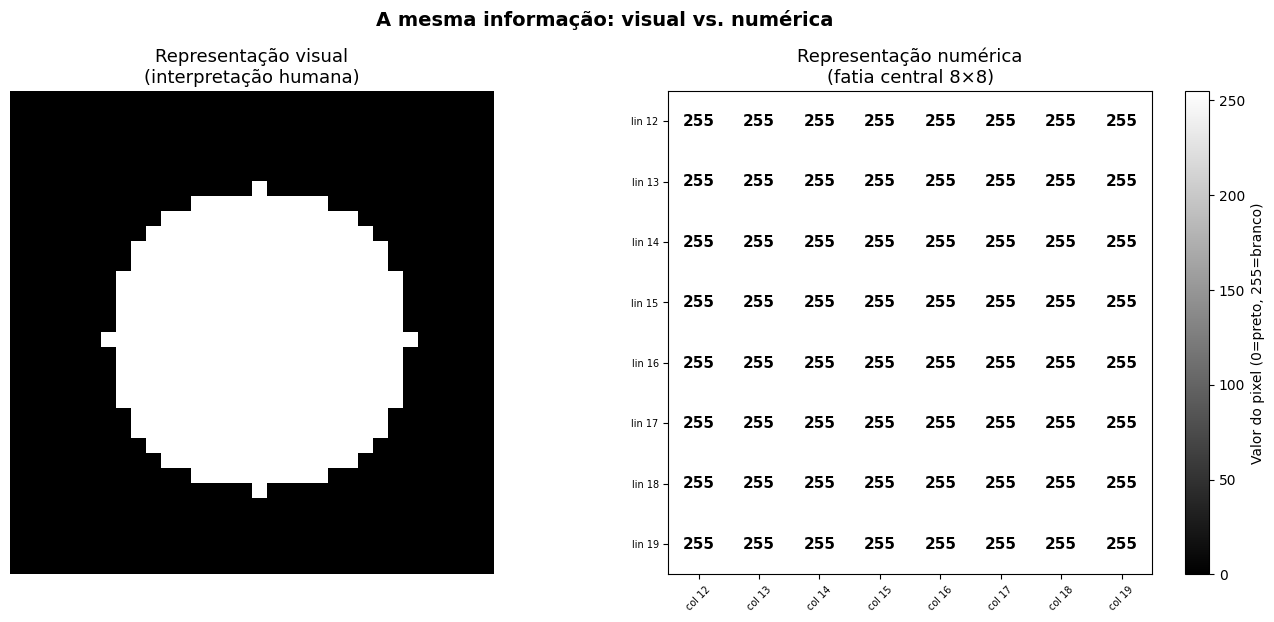

Não há círculo aqui. Há uma matriz de números.
O "círculo" é uma interpretação humana de um padrão numérico.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: imagem visual
axes[0].imshow(circulo, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Representação visual\n(interpretação humana)', fontsize=13)
axes[0].axis('off')

# Plot 2: heatmap com valores anotados
# Usar apenas a fatia central 8x8 para caber os números
fatia_vis = circulo[12:20, 12:20]
im = axes[1].imshow(fatia_vis, cmap='gray', vmin=0, vmax=255)

# Anotar cada célula com seu valor numérico
for i in range(fatia_vis.shape[0]):
    for j in range(fatia_vis.shape[1]):
        valor = fatia_vis[i, j]
        # Cor do texto: branco em fundo preto, preto em fundo branco
        cor_texto = 'white' if valor < 128 else 'black'
        axes[1].text(j, i, str(valor), ha='center', va='center',
                     fontsize=11, color=cor_texto, fontweight='bold')

axes[1].set_title('Representação numérica\n(fatia central 8×8)', fontsize=13)
axes[1].set_xticks(range(8))
axes[1].set_yticks(range(8))
axes[1].set_xticklabels([f'col {12+i}' for i in range(8)], fontsize=7, rotation=45)
axes[1].set_yticklabels([f'lin {12+i}' for i in range(8)], fontsize=7)

plt.colorbar(im, ax=axes[1], label='Valor do pixel (0=preto, 255=branco)')
plt.suptitle('A mesma informação: visual vs. numérica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Não há círculo aqui. Há uma matriz de números.')
print('O "círculo" é uma interpretação humana de um padrão numérico.')


### Os 3 canais RGB separadamente

Imagens coloridas têm **3 canais**: Red (vermelho), Green (verde), Blue (azul).
Cada canal é uma matriz independente de valores 0–255.
A cor que "vemos" é a combinação dessas 3 matrizes.

Vamos criar uma versão colorida do círculo e separar os canais:


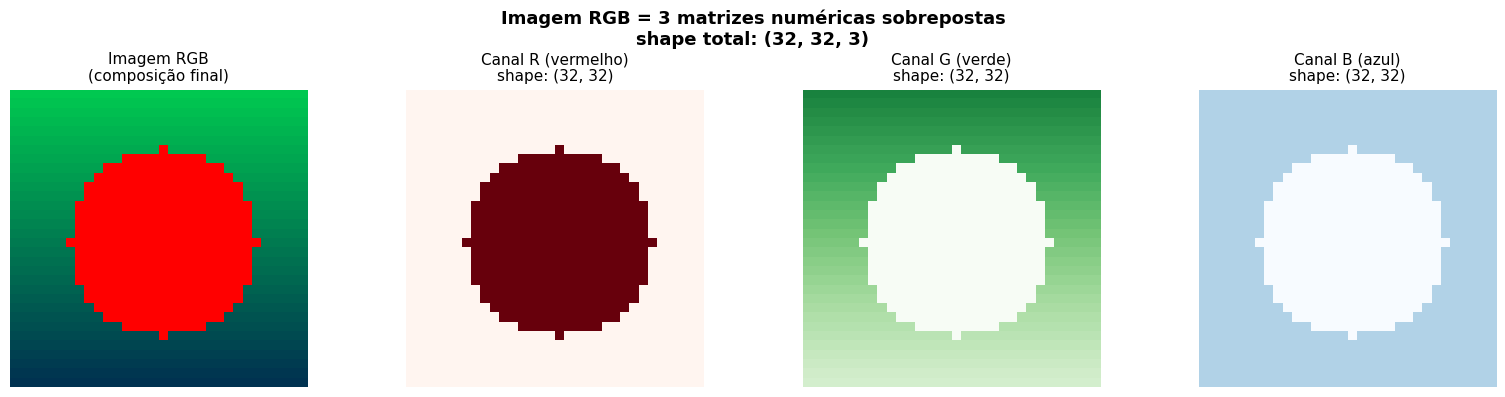

Shape da imagem RGB: (32, 32, 3)
Total de números que descrevem esta imagem: 3072 = 32 × 32 × 3
Cada número: inteiro de 0 a 255 (1 byte)
Tamanho total: 3072 bytes = 3.00 KB


In [3]:
# Criar imagem RGB 32x32x3
# Canal R: círculo vermelho
# Canal G: gradiente verde de baixo para cima
# Canal B: fundo azul com o círculo em azul escuro

imagem_rgb = np.zeros((32, 32, 3), dtype=np.uint8)

# Canal R: o círculo original em vermelho
imagem_rgb[:, :, 0] = circulo  # vermelho onde há círculo

# Canal G: gradiente vertical (mais verde em cima)
gradiente_verde = np.tile(np.linspace(200, 50, 32).astype(np.uint8), (32, 1)).T
imagem_rgb[:, :, 1] = gradiente_verde * (circulo == 0)  # verde apenas no fundo

# Canal B: fundo azul escuro
imagem_rgb[:, :, 2] = 80 * (circulo == 0)  # azul apenas no fundo

# Plotar imagem completa + 3 canais separados
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

nomes = ['Imagem RGB\n(composição final)', 'Canal R (vermelho)', 'Canal G (verde)', 'Canal B (azul)']
cmaps = [None, 'Reds', 'Greens', 'Blues']

# Imagem completa RGB
axes[0].imshow(imagem_rgb)
axes[0].set_title(nomes[0], fontsize=11)
axes[0].axis('off')

# Cada canal separado
for i, (canal, nome, cmap) in enumerate(zip([0, 1, 2], nomes[1:], cmaps[1:])):
    axes[i+1].imshow(imagem_rgb[:, :, canal], cmap=cmap, vmin=0, vmax=255)
    axes[i+1].set_title(f'{nome}\nshape: (32, 32)', fontsize=11)
    axes[i+1].axis('off')
    # Mostrar valor médio do canal
    media = imagem_rgb[:, :, canal].mean()
    axes[i+1].set_xlabel(f'Valor médio: {media:.1f}', fontsize=9)

plt.suptitle('Imagem RGB = 3 matrizes numéricas sobrepostas\nshape total: (32, 32, 3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Shape da imagem RGB: {imagem_rgb.shape}')
print(f'Total de números que descrevem esta imagem: {imagem_rgb.size} = 32 × 32 × 3')
print(f'Cada número: inteiro de 0 a 255 (1 byte)')
print(f'Tamanho total: {imagem_rgb.nbytes} bytes = {imagem_rgb.nbytes/1024:.2f} KB')


> **Não há círculo aqui. Há uma matriz de números. O 'círculo' é uma interpretação humana de um padrão numérico.**

Esta distinção é fundamental: quando um modelo de visão "reconhece" um círculo, ele identifica padrões estatísticos no array numérico — não o conceito geométrico de círculo.


## Parte 3 — Filtros Manuais: Convolução

A operação fundamental de toda CNN (Convolutional Neural Network) é a **convolução**.
Mas antes de deixar o PyTorch fazer isso automaticamente, vamos implementar manualmente.

### O que é uma convolução?

Uma convolução 2D desliza um filtro pequeno (ex: 3×3) por toda a imagem.
Em cada posição, multiplica os valores do filtro pelos pixels correspondentes e soma tudo.
O resultado é um único número — o pixel de saída naquela posição.

```
Imagem (pedaço 3×3):    Filtro 3×3:        Resultado:
  [a b c]              [f1 f2 f3]         a*f1 + b*f2 + c*f3
  [d e f]     ⊛        [f4 f5 f6]    →  + d*f4 + e*f5 + f*f6
  [g h i]              [f7 f8 f9]       + g*f7 + h*f8 + i*f9
```

Isso se repete para cada posição da imagem. O filtro "varre" a imagem inteira.


In [4]:
def conv2d_manual(imagem, filtro):
    """
    Convolução 2D implementada em numpy puro.
    
    Parâmetros:
        imagem: array 2D de shape (H, W) — a imagem de entrada
        filtro: array 2D de shape (fh, fw) — o filtro/kernel
    
    Retorna:
        resultado: array 2D de shape (H - fh + 1, W - fw + 1)
        (sem padding, então o resultado é ligeiramente menor que a entrada)
    """
    # Obter dimensões da imagem e do filtro
    H, W = imagem.shape        # altura e largura da imagem
    fh, fw = filtro.shape      # altura e largura do filtro
    
    # Calcular dimensões da saída (sem padding)
    # A cada passo, o filtro se move 1 pixel (stride=1)
    # O filtro cabe em (H - fh + 1) posições verticais
    # e (W - fw + 1) posições horizontais
    H_out = H - fh + 1
    W_out = W - fw + 1
    
    # Inicializar a saída com zeros (float para suportar valores negativos)
    resultado = np.zeros((H_out, W_out), dtype=np.float64)
    
    # Loop duplo: iterar por todas as posições válidas do filtro
    for i in range(H_out):          # i = linha do pixel de saída
        for j in range(W_out):      # j = coluna do pixel de saída
            # Extrair o patch (pedaço) da imagem onde o filtro se aplica
            # O patch vai da linha i até i+fh, coluna j até j+fw
            patch = imagem[i:i+fh, j:j+fw]
            
            # Multiplicação elemento a elemento (Hadamard) + soma
            # Esta é a operação de correlação cruzada (o que CNNs realmente fazem)
            resultado[i, j] = np.sum(patch * filtro)
    
    return resultado


# Definir os 4 filtros clássicos

# 1. Identidade — reproduz a imagem sem alteração
filtro_identidade = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
], dtype=np.float64)

# 2. Blur (média 3×3) — suaviza a imagem, reduz ruído
# Cada pixel de saída = média dos 9 pixels vizinhos
filtro_blur = np.ones((3, 3), dtype=np.float64) / 9.0

# 3. Sobel X — detecta bordas na direção horizontal
# Pixels à esquerda recebem peso negativo, à direita positivo
# Onde a intensidade muda horizontalmente, o resultado é alto
filtro_sobel_x = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float64)

# 4. Sobel Y — detecta bordas na direção vertical
# Pixels acima recebem peso negativo, abaixo positivo
filtro_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float64)

# Mostrar os filtros como arrays numéricos
print('=== Os filtros são apenas matrizes de números ===')
print()
for nome, filtro in [('Identidade', filtro_identidade),
                      ('Blur (média 3×3)', filtro_blur),
                      ('Sobel X (bordas horizontais)', filtro_sobel_x),
                      ('Sobel Y (bordas verticais)', filtro_sobel_y)]:
    print(f'Filtro: {nome}')
    print(filtro)
    print()


=== Os filtros são apenas matrizes de números ===

Filtro: Identidade
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]

Filtro: Blur (média 3×3)
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Filtro: Sobel X (bordas horizontais)
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Filtro: Sobel Y (bordas verticais)
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]



Shapes dos resultados (sem padding, filtro 3×3 reduz 2 pixels em cada dimensão):
  Original:    (32, 32)
  Após conv2d: (30, 30)  (32-3+1 = 30)


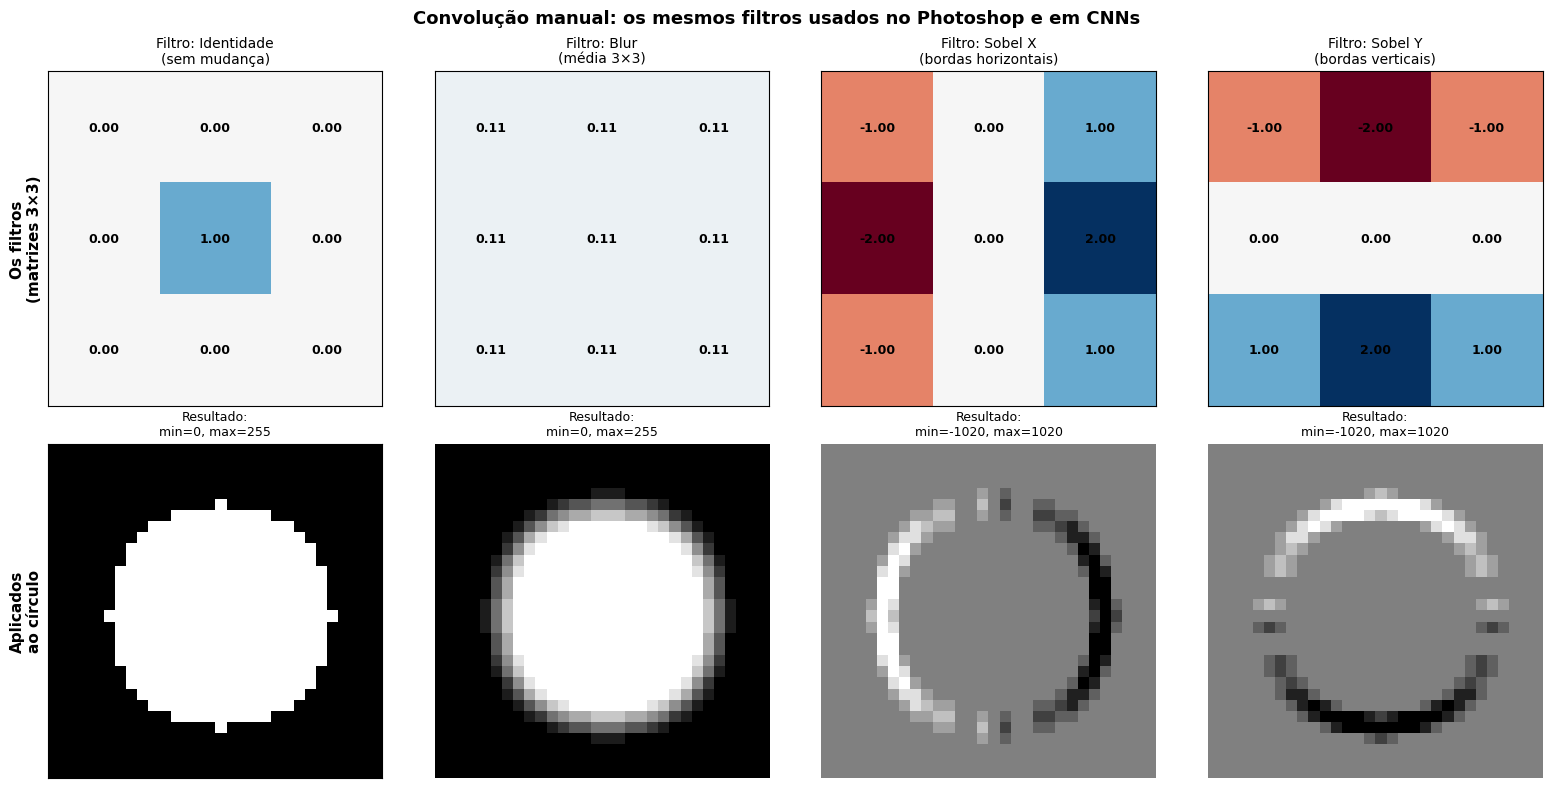

In [5]:
# Converter imagem para float para as convoluções
circulo_float = circulo.astype(np.float64)

# Aplicar os 4 filtros
resultado_identidade = conv2d_manual(circulo_float, filtro_identidade)
resultado_blur = conv2d_manual(circulo_float, filtro_blur)
resultado_sobel_x = conv2d_manual(circulo_float, filtro_sobel_x)
resultado_sobel_y = conv2d_manual(circulo_float, filtro_sobel_y)

print('Shapes dos resultados (sem padding, filtro 3×3 reduz 2 pixels em cada dimensão):')
print(f'  Original:    {circulo_float.shape}')
print(f'  Após conv2d: {resultado_identidade.shape}  (32-3+1 = 30)')

# Plotar resultados
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

filtros = [filtro_identidade, filtro_blur, filtro_sobel_x, filtro_sobel_y]
resultados = [resultado_identidade, resultado_blur, resultado_sobel_x, resultado_sobel_y]
nomes = ['Identidade\n(sem mudança)', 'Blur\n(média 3×3)',
         'Sobel X\n(bordas horizontais)', 'Sobel Y\n(bordas verticais)']

# Linha 1: os filtros visualizados
for i, (filtro, nome) in enumerate(zip(filtros, nomes)):
    axes[0, i].imshow(filtro, cmap='RdBu', vmin=-2, vmax=2)
    axes[0, i].set_title(f'Filtro: {nome}', fontsize=10)
    # Anotar valores
    for r in range(3):
        for c in range(3):
            axes[0, i].text(c, r, f'{filtro[r,c]:.2f}',
                            ha='center', va='center', fontsize=9, fontweight='bold')
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

# Linha 2: resultados aplicados ao círculo
for i, (resultado, nome) in enumerate(zip(resultados, nomes)):
    # Normalizar para visualização
    vmin = resultado.min()
    vmax = resultado.max()
    axes[1, i].imshow(resultado, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, i].set_title(f'Resultado:\nmin={vmin:.0f}, max={vmax:.0f}', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Os filtros\n(matrizes 3×3)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Aplicados\nao círculo', fontsize=11, fontweight='bold')
axes[1, 0].axis('on')
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

plt.suptitle('Convolução manual: os mesmos filtros usados no Photoshop e em CNNs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **O detector de bordas do Photoshop e o primeiro layer de uma CNN são a mesma operação matemática.**
> **A diferença é que a CNN aprende os coeficientes do filtro — não recebe eles prontos.**

Os filtros Sobel acima foram *escritos à mão* por engenheiros de visão computacional nos anos 1960–1980.
Uma CNN com 8 filtros na primeira camada aprende **8 matrizes de coeficientes** diretamente dos dados,
via gradiente descendente — sem nenhum humano decidir o que cada filtro deve detectar.


## Parte 4 — O Problema: Pixel a Pixel Não Basta

Se imagens são apenas arrays de números, por que não comparar imagens diretamente pixel a pixel?
Por que precisamos de filtros, convoluções e redes neurais?

Esta parte demonstra o problema central: **translação**.

Um círculo no canto superior esquerdo e o mesmo círculo no centro são,
para um humano, o *mesmo objeto em posições diferentes*.
Para uma comparação pixel a pixel, são completamente diferentes.


Distâncias Euclidianas entre círculos IDÊNTICOS em posições diferentes:
  Canto sup. esq. ↔ Centro:           dist = 3782.3
  Canto sup. esq. ↔ Canto inf. dir.:  dist = 3833.5
  Centro ↔ Canto inf. dir.:           dist = 3782.3

Círculos geometricamente idênticos têm distância GRANDE pixel a pixel!
Para um comparador de pixels, eles são "objetos completamente diferentes".


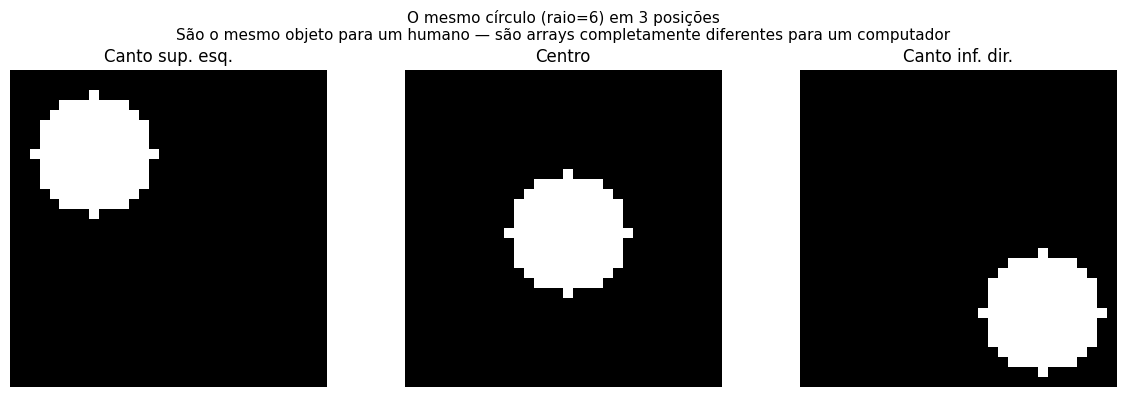

In [6]:
# Gerar 3 círculos idênticos mas em posições diferentes
circulo_esquerda_cima = criar_circulo_basico(tamanho=32, cx=8, cy=8, raio=6)
circulo_centro = criar_circulo_basico(tamanho=32, cx=16, cy=16, raio=6)
circulo_direita_baixo = criar_circulo_basico(tamanho=32, cx=24, cy=24, raio=6)

# Calcular distância euclidiana pixel a pixel entre os arrays
def distancia_euclidiana(img1, img2):
    """
    Distância L2 (Euclidiana) entre dois arrays de imagem.
    Trata cada imagem como um vetor de (H*W) dimensões.
    
    dist = sqrt(sum((pixel1 - pixel2)^2))
    """
    return np.sqrt(np.sum((img1.astype(float) - img2.astype(float))**2))

d_esq_cen = distancia_euclidiana(circulo_esquerda_cima, circulo_centro)
d_esq_dir = distancia_euclidiana(circulo_esquerda_cima, circulo_direita_baixo)
d_cen_dir = distancia_euclidiana(circulo_centro, circulo_direita_baixo)

print('Distâncias Euclidianas entre círculos IDÊNTICOS em posições diferentes:')
print(f'  Canto sup. esq. ↔ Centro:           dist = {d_esq_cen:.1f}')
print(f'  Canto sup. esq. ↔ Canto inf. dir.:  dist = {d_esq_dir:.1f}')
print(f'  Centro ↔ Canto inf. dir.:           dist = {d_cen_dir:.1f}')
print()
print('Círculos geometricamente idênticos têm distância GRANDE pixel a pixel!')
print('Para um comparador de pixels, eles são "objetos completamente diferentes".')

# Visualizar os 3 círculos
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, titulo in zip(axes,
                             [circulo_esquerda_cima, circulo_centro, circulo_direita_baixo],
                             ['Canto sup. esq.', 'Centro', 'Canto inf. dir.']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(titulo, fontsize=12)
    ax.axis('off')
    ax.set_xlabel(f'Shape: {img.shape}', fontsize=9)

plt.suptitle('O mesmo círculo (raio=6) em 3 posições\nSão o mesmo objeto para um humano — são arrays completamente diferentes para um computador',
             fontsize=11)
plt.tight_layout()
plt.show()


Comparação: ruído gaussiano vs. translação de 2 pixels
  Distância com ruído (σ=20):          449.1
  Distância com translação de 2px:    1766.7

Uma translação de apenas 2 pixels gera distância MAIOR
do que adicionar ruído gaussiano significativo (σ=20/255)!


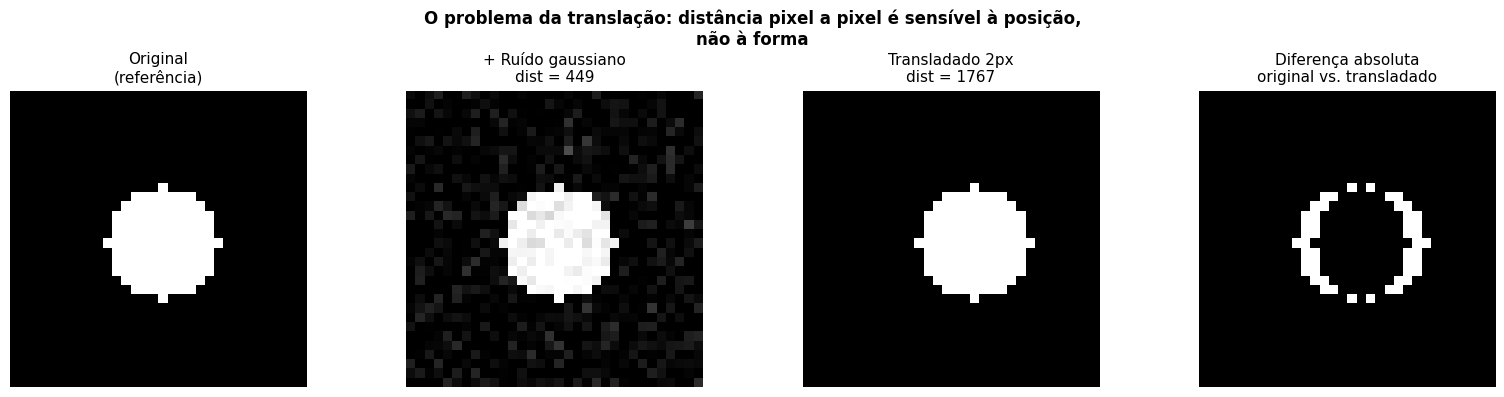

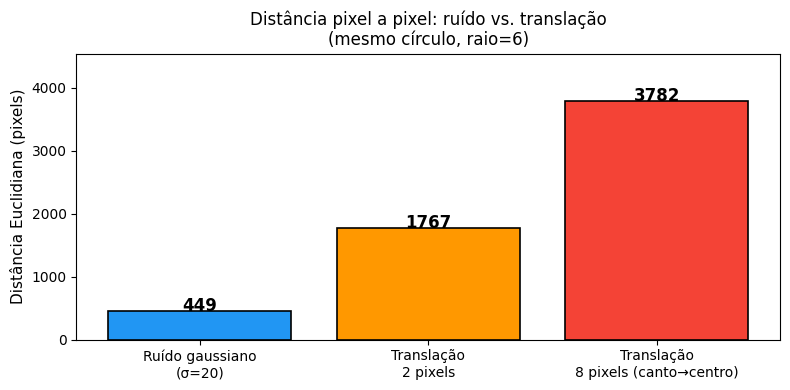

In [7]:
# Demonstrar que ruído pequeno gera distância menor do que translação

# Adicionar ruído gaussiano ao círculo central
ruido = np.random.normal(0, 20, circulo_centro.shape)  # desvio padrão = 20 (de 0-255)
circulo_com_ruido = np.clip(circulo_centro.astype(float) + ruido, 0, 255).astype(np.uint8)

# Transladar o círculo central 2 pixels para a direita
circulo_transladado_2px = criar_circulo_basico(tamanho=32, cx=18, cy=16, raio=6)  # cx+2

# Calcular distâncias
d_ruido = distancia_euclidiana(circulo_centro, circulo_com_ruido)
d_translacao_2px = distancia_euclidiana(circulo_centro, circulo_transladado_2px)

print('Comparação: ruído gaussiano vs. translação de 2 pixels')
print(f'  Distância com ruído (σ=20):          {d_ruido:.1f}')
print(f'  Distância com translação de 2px:    {d_translacao_2px:.1f}')
print()
print('Uma translação de apenas 2 pixels gera distância MAIOR')
print('do que adicionar ruído gaussiano significativo (σ=20/255)!')

# Visualização comparativa
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

imagens_comp = [circulo_centro, circulo_com_ruido, circulo_transladado_2px,
                np.abs(circulo_centro.astype(int) - circulo_transladado_2px.astype(int))]
titulos = ['Original\n(referência)',
           f'+ Ruído gaussiano\ndist = {d_ruido:.0f}',
           f'Transladado 2px\ndist = {d_translacao_2px:.0f}',
           'Diferença absoluta\noriginal vs. transladado']

for ax, img, titulo in zip(axes, imagens_comp, titulos):
    ax.imshow(img, cmap='gray')
    ax.set_title(titulo, fontsize=11)
    ax.axis('off')

plt.suptitle('O problema da translação: distância pixel a pixel é sensível à posição,\nnão à forma',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar chart comparativo
fig, ax = plt.subplots(figsize=(8, 4))
categorias = ['Ruído gaussiano\n(σ=20)', 'Translação\n2 pixels', 'Translação\n8 pixels (canto→centro)']
d_translacao_8px = distancia_euclidiana(circulo_esquerda_cima, circulo_centro)
valores = [d_ruido, d_translacao_2px, d_translacao_8px]
cores = ['#2196F3', '#FF9800', '#F44336']
barras = ax.bar(categorias, valores, color=cores, edgecolor='black', linewidth=1.2)
for barra, val in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 5,
            f'{val:.0f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Distância Euclidiana (pixels)', fontsize=11)
ax.set_title('Distância pixel a pixel: ruído vs. translação\n(mesmo círculo, raio=6)', fontsize=12)
ax.set_ylim(0, max(valores) * 1.2)
plt.tight_layout()
plt.show()


> **É por isso que filtros locais (convolução) existem — eles capturam padrões independente da posição exata. Isso se chama invariância translacional.**

Um filtro detector de borda produzirá ativação alta onde há bordas **independente de onde na imagem** as bordas estejam.
O MaxPooling (que veremos na Parte 6) reforça ainda mais essa invariância.


## Parte 5 — Corpus Sintético de Formas Geométricas

Agora construímos nosso *dataset* completamente sintético.
Nenhum download, nenhuma imagem real — apenas geometria gerada programaticamente.

**Três classes:**
- Classe 0: círculos preenchidos
- Classe 1: quadrados preenchidos
- Classe 2: triângulos isósceles preenchidos

Cada imagem é 32×32 pixels, escala de cinza (1 canal), com variação aleatória de:
- Tamanho da forma
- Posição na imagem
- Nível de ruído gaussiano

O objetivo é que a CNN aprenda a distinguir as formas **apesar** dessas variações.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ============================================================
# Funções geradoras de formas geométricas
# ============================================================

def gerar_circulo(tamanho=32, raio_min=6, raio_max=12, ruido=0.1, seed=None):
    """
    Gera imagem 32×32 com um círculo preenchido.
    
    - Centro aleatório (com margem para o círculo caber inteiro)
    - Raio aleatório entre raio_min e raio_max
    - Ruído gaussiano adicionado
    - Retorna array (32, 32) com valores float em [0, 1]
    """
    rng = np.random.RandomState(seed)
    
    # Sortear raio e centro com margem suficiente
    raio = rng.randint(raio_min, raio_max + 1)
    margem = raio + 1
    cx = rng.randint(margem, tamanho - margem)
    cy = rng.randint(margem, tamanho - margem)
    
    # Criar grades de coordenadas
    y, x = np.ogrid[:tamanho, :tamanho]  # np.ogrid cria vetores coluna e linha
    
    # Máscara booleana: True onde o pixel está dentro do círculo
    mascara = (x - cx)**2 + (y - cy)**2 <= raio**2
    
    # Criar imagem: 1.0 dentro do círculo, 0.0 fora
    imagem = mascara.astype(np.float32)
    
    # Adicionar ruído gaussiano e clipar para [0, 1]
    imagem += rng.normal(0, ruido, imagem.shape).astype(np.float32)
    imagem = np.clip(imagem, 0.0, 1.0)
    
    return imagem


def gerar_quadrado(tamanho=32, lado_min=8, lado_max=16, ruido=0.1, seed=None):
    """
    Gera imagem 32×32 com um quadrado preenchido.
    
    - Posição superior-esquerda aleatória (com margem)
    - Lado aleatório entre lado_min e lado_max
    - Ruído gaussiano adicionado
    - Retorna array (32, 32) com valores float em [0, 1]
    """
    rng = np.random.RandomState(seed)
    
    # Sortear lado e posição
    lado = rng.randint(lado_min, lado_max + 1)
    margem = 2
    x0 = rng.randint(margem, tamanho - lado - margem)
    y0 = rng.randint(margem, tamanho - lado - margem)
    
    # Inicializar imagem preta
    imagem = np.zeros((tamanho, tamanho), dtype=np.float32)
    
    # Preencher o quadrado — operação de slice (sem loops)
    imagem[y0:y0+lado, x0:x0+lado] = 1.0
    
    # Adicionar ruído gaussiano e clipar
    imagem += rng.normal(0, ruido, imagem.shape).astype(np.float32)
    imagem = np.clip(imagem, 0.0, 1.0)
    
    return imagem


def gerar_triangulo(tamanho=32, base_min=10, base_max=18, ruido=0.1, seed=None):
    """
    Gera imagem 32×32 com um triângulo isósceles preenchido.
    
    Usa rasterização por varredura de linhas (scanline rendering):
    - Define os 3 vértices do triângulo
    - Para cada linha horizontal (scanline), calcula onde as bordas
      do triângulo cruzam essa linha
    - Preenche os pixels entre o cruzamento esquerdo e direito
    
    Retorna array (32, 32) com valores float em [0, 1]
    """
    rng = np.random.RandomState(seed)
    
    # Sortear base e posição
    base = rng.randint(base_min, base_max + 1)
    altura = int(base * 0.866)  # triângulo equilátero: h = b * sqrt(3)/2
    altura = max(altura, 6)     # garantir altura mínima
    
    margem = 2
    # cx: centro horizontal da base
    cx = rng.randint(base // 2 + margem, tamanho - base // 2 - margem)
    # y_base: linha da base (parte inferior do triângulo)
    y_base = rng.randint(altura + margem, tamanho - margem)
    y_topo = y_base - altura  # vértice superior
    
    # 3 vértices: topo (centro), base-esquerda, base-direita
    v_topo = (cx, y_topo)
    v_esq = (cx - base // 2, y_base)
    v_dir = (cx + base // 2, y_base)
    
    # Inicializar imagem preta
    imagem = np.zeros((tamanho, tamanho), dtype=np.float32)
    
    # Varredura de linhas (scanline rendering)
    # Para cada linha y entre y_topo e y_base:
    for y in range(max(0, y_topo), min(tamanho, y_base + 1)):
        # Progresso: 0 no topo, 1 na base
        if y_base == y_topo:  # evitar divisão por zero
            continue
        t = (y - y_topo) / (y_base - y_topo)
        
        # Interpolar a posição x das bordas esquerda e direita
        # Lado esquerdo: do topo até v_esq
        x_esq = v_topo[0] + t * (v_esq[0] - v_topo[0])
        # Lado direito: do topo até v_dir
        x_dir = v_topo[0] + t * (v_dir[0] - v_topo[0])
        
        # Converter para inteiros e preencher a linha
        x_ini = max(0, int(x_esq))
        x_fim = min(tamanho, int(x_dir) + 1)
        imagem[y, x_ini:x_fim] = 1.0
    
    # Adicionar ruído gaussiano e clipar
    imagem += rng.normal(0, ruido, imagem.shape).astype(np.float32)
    imagem = np.clip(imagem, 0.0, 1.0)
    
    return imagem


# Testar as funções
print('Testando geradores de formas...')
c = gerar_circulo(seed=0)
q = gerar_quadrado(seed=0)
t = gerar_triangulo(seed=0)
print(f'Círculo   — shape: {c.shape}, dtype: {c.dtype}, min: {c.min():.3f}, max: {c.max():.3f}')
print(f'Quadrado  — shape: {q.shape}, dtype: {q.dtype}, min: {q.min():.3f}, max: {q.max():.3f}')
print(f'Triângulo — shape: {t.shape}, dtype: {t.dtype}, min: {t.min():.3f}, max: {t.max():.3f}')


Testando geradores de formas...
Círculo   — shape: (32, 32), dtype: float32, min: 0.000, max: 1.000
Quadrado  — shape: (32, 32), dtype: float32, min: 0.000, max: 1.000
Triângulo — shape: (32, 32), dtype: float32, min: 0.000, max: 1.000


In [9]:
# ============================================================
# Gerar o dataset completo
# ============================================================

N_POR_CLASSE = 200  # 200 amostras de cada forma
TAMANHO = 32

# Gerar todas as imagens
# Cada grupo de seeds garante reprodutibilidade
circulos = np.array([gerar_circulo(seed=i)   for i in range(N_POR_CLASSE)])
quadrados = np.array([gerar_quadrado(seed=i)  for i in range(N_POR_CLASSE)])
triangulos = np.array([gerar_triangulo(seed=i) for i in range(N_POR_CLASSE)])

# Labels: 0=círculo, 1=quadrado, 2=triângulo
labels_circ = np.zeros(N_POR_CLASSE, dtype=np.int64)
labels_quad = np.ones(N_POR_CLASSE, dtype=np.int64)
labels_tri = np.full(N_POR_CLASSE, 2, dtype=np.int64)

# Concatenar tudo
X_todos = np.concatenate([circulos, quadrados, triangulos], axis=0)  # shape: (600, 32, 32)
y_todos = np.concatenate([labels_circ, labels_quad, labels_tri])      # shape: (600,)

# Adicionar dimensão de canal: (600, 1, 32, 32) — formato esperado pelo PyTorch
X_todos = X_todos[:, np.newaxis, :, :]  # inserir canal na posição 1

print(f'Dataset completo:')
print(f'  X shape: {X_todos.shape}  (amostras, canais, altura, largura)')
print(f'  y shape: {y_todos.shape}')
print(f'  Distribuição de classes: {dict(zip(["círculo","quadrado","triângulo"], [np.sum(y_todos==i) for i in range(3)]))}')

# Split 80/20 treino/teste
# Embaralhar antes do split para misturar as classes
indices = np.random.permutation(len(X_todos))
n_treino = int(0.8 * len(X_todos))  # 480 para treino

idx_treino = indices[:n_treino]
idx_teste = indices[n_treino:]

X_treino = X_todos[idx_treino]
y_treino = y_todos[idx_treino]
X_teste = X_todos[idx_teste]
y_teste = y_todos[idx_teste]

print(f'\nSplit 80/20:')
print(f'  Treino: {X_treino.shape[0]} amostras')
print(f'  Teste:  {X_teste.shape[0]} amostras')
print(f'  Classes no treino: {dict(zip(["círculo","quadrado","triângulo"], [np.sum(y_treino==i) for i in range(3)]))}')


Dataset completo:
  X shape: (600, 1, 32, 32)  (amostras, canais, altura, largura)
  y shape: (600,)
  Distribuição de classes: {'círculo': np.int64(200), 'quadrado': np.int64(200), 'triângulo': np.int64(200)}

Split 80/20:
  Treino: 480 amostras
  Teste:  120 amostras
  Classes no treino: {'círculo': np.int64(162), 'quadrado': np.int64(159), 'triângulo': np.int64(159)}


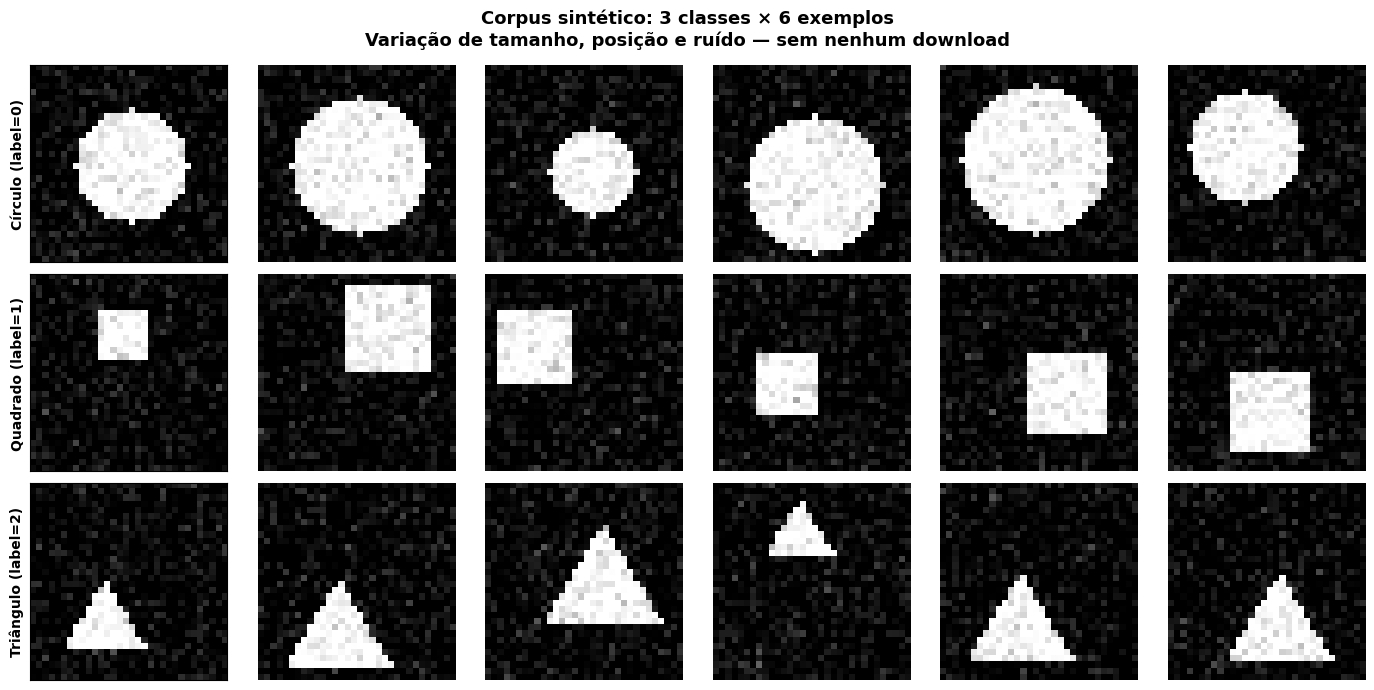

Corpus gerado. Próximo passo: treinar uma CNN para classificar essas formas.


In [10]:
# Visualizar grade de exemplos: 3 linhas (uma por classe), 6 colunas

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
nomes_classes = ['Círculo (label=0)', 'Quadrado (label=1)', 'Triângulo (label=2)']
geradores = [gerar_circulo, gerar_quadrado, gerar_triangulo]

for linha, (nome, gerador) in enumerate(zip(nomes_classes, geradores)):
    for col in range(6):
        # Usar seeds diferentes para mostrar variação
        seed = linha * 100 + col * 17 + 5
        img = gerador(seed=seed)
        axes[linha, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[linha, col].axis('off')
        if col == 0:
            axes[linha, col].set_ylabel(nome, fontsize=10, fontweight='bold')
            axes[linha, col].axis('on')
            axes[linha, col].set_xticks([])
            axes[linha, col].set_yticks([])

plt.suptitle('Corpus sintético: 3 classes × 6 exemplos\n'
             'Variação de tamanho, posição e ruído — sem nenhum download',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Corpus gerado. Próximo passo: treinar uma CNN para classificar essas formas.')


## Parte 6 — CNN Básica (PyTorch)

Agora implementamos uma CNN (*Convolutional Neural Network*) para classificar as 3 formas.
Cada componente é comentado para conectar com o que vimos nas Partes 3 e 4.

### Arquitetura

```
Entrada: (batch, 1, 32, 32)  — imagem grayscale 32×32
    ↓
Conv2d(1→8, kernel=3×3) + ReLU + MaxPool(2×2)
    ↓
Conv2d(8→16, kernel=3×3) + ReLU + MaxPool(2×2)
    ↓
Flatten
    ↓
Linear(features→32) + ReLU
    ↓
Linear(32→3)  — logits para 3 classes
    ↓
Saída: (batch, 3)  — scores não-normalizados
```

### Por que cada componente existe?

| Componente | Papel |
|---|---|
| **Conv2d** | Aprende filtros (como os da Parte 3, mas os coeficientes são aprendidos) |
| **ReLU** | Não-linearidade — sem ela, empilhar camadas colapsaria para uma única transformação linear |
| **MaxPool** | Reduz resolução espacial; aumenta invariância translacional |
| **Flatten** | Converte feature map 2D em vetor 1D para as camadas densas |
| **Linear** | Combina features extraídas para decisão final |


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Semente para reprodutibilidade
torch.manual_seed(42)


class CNNFormas(nn.Module):
    """
    CNN para classificação de formas geométricas.
    
    Segue o padrão clássico: blocos conv+relu+pool para extração de features,
    seguidos de camadas densas para classificação.
    """
    def __init__(self):
        super(CNNFormas, self).__init__()
        
        # === BLOCO 1: Conv + ReLU + MaxPool ===
        # Conv2d(in_channels=1, out_channels=8, kernel_size=3)
        # - in_channels=1: imagem grayscale (1 canal)
        # - out_channels=8: vamos aprender 8 filtros diferentes
        # - kernel_size=3: cada filtro é 3×3 (como os da Parte 3)
        # - padding=1: zero-padding para manter a resolução espacial
        # Parâmetros: 8 × (1 × 3 × 3) pesos + 8 biases = 80 parâmetros
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        # ReLU: f(x) = max(0, x) — zera valores negativos
        # Isso cria não-linearidade essencial para aprender funções complexas
        self.relu1 = nn.ReLU()
        # MaxPool2d: em cada janela 2×2, mantém o valor máximo
        # Reduz (32×32) para (16×16), aumenta invariância translacional
        self.pool1 = nn.MaxPool2d(2, 2)  # kernel=2, stride=2
        
        # === BLOCO 2: Conv + ReLU + MaxPool ===
        # Conv2d(in_channels=8, out_channels=16, kernel_size=3)
        # - Recebe os 8 feature maps do bloco anterior
        # - Produz 16 feature maps mais abstratos
        # Parâmetros: 16 × (8 × 3 × 3) pesos + 16 biases = 1168 parâmetros
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        # Reduz (16×16) para (8×8)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # === BLOCO DENSO: Classificação ===
        # Após os dois blocos conv+pool: (batch, 16, 8, 8)
        # Flatten: 16 × 8 × 8 = 1024 features
        self.flatten = nn.Flatten()
        
        # Camada densa 1: 1024 → 32
        # Combina todos os features extraídos pelas convoluções
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.relu3 = nn.ReLU()
        
        # Camada de saída: 32 → 3 (uma pontuação por classe)
        # Não tem softmax aqui — o CrossEntropyLoss já inclui softmax internamente
        self.fc2 = nn.Linear(32, 3)
    
    def forward(self, x):
        """Passo forward: define como os dados fluem pela rede."""
        # Bloco 1
        x = self.pool1(self.relu1(self.conv1(x)))
        # Bloco 2
        x = self.pool2(self.relu2(self.conv2(x)))
        # Classificação
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x  # logits: valores brutos antes do softmax


# Instanciar o modelo
modelo = CNNFormas()

# Contar e detalhar parâmetros
print('=== Arquitetura da CNN ===')
print(modelo)
print()
print('=== Parâmetros por camada ===')
total = 0
for nome, param in modelo.named_parameters():
    n = param.numel()
    total += n
    print(f'  {nome:20s}  shape={str(param.shape):20s}  params={n:5d}')
print(f'  {"TOTAL":20s}  {"":20s}  params={total:5d}')
print()
print(f'Comparação: GPT-2 tem 117 milhões de parâmetros. Nossa CNN tem {total}.')
print('Para imagens 32×32 em 3 classes, {total} parâmetros são suficientes.')


=== Arquitetura da CNN ===
CNNFormas(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=32, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)

=== Parâmetros por camada ===
  conv1.weight          shape=torch.Size([8, 1, 3, 3])  params=   72
  conv1.bias            shape=torch.Size([8])       params=    8
  conv2.weight          shape=torch.Size([16, 8, 3, 3])  params= 1152
  conv2.bias            shape=torch.Size([16])      params=   16
  fc1.weight            shape=torch.Size([32, 1024])  params=32768
  fc1.bias              shape=torch.Size([32])   

In [12]:
# Verificar as dimensões dos tensores em cada camada
# Fazer um passo forward com um batch de 1 imagem

x_teste_shape = torch.zeros(1, 1, 32, 32)  # batch=1, canal=1, 32×32

print('Dimensões dos tensores ao longo da rede:')
print(f'  Entrada:          {tuple(x_teste_shape.shape)}')

x = modelo.conv1(x_teste_shape)
print(f'  Após conv1:       {tuple(x.shape)}  (8 filtros, 32×32 com padding)')
x = modelo.relu1(x)
print(f'  Após relu1:       {tuple(x.shape)}  (mesma shape)')
x = modelo.pool1(x)
print(f'  Após pool1:       {tuple(x.shape)}  (32×32 → 16×16)')
x = modelo.conv2(x)
print(f'  Após conv2:       {tuple(x.shape)}  (8→16 filtros)')
x = modelo.relu2(x)
x = modelo.pool2(x)
print(f'  Após pool2:       {tuple(x.shape)}  (16×16 → 8×8)')
x = modelo.flatten(x)
print(f'  Após flatten:     {tuple(x.shape)}  (16 × 8 × 8 = 1024)')
x = modelo.relu3(modelo.fc1(x))
print(f'  Após fc1+relu:    {tuple(x.shape)}  (1024 → 32)')
x = modelo.fc2(x)
print(f'  Saída (logits):   {tuple(x.shape)}  (32 → 3 classes)')


Dimensões dos tensores ao longo da rede:
  Entrada:          (1, 1, 32, 32)
  Após conv1:       (1, 8, 32, 32)  (8 filtros, 32×32 com padding)
  Após relu1:       (1, 8, 32, 32)  (mesma shape)
  Após pool1:       (1, 8, 16, 16)  (32×32 → 16×16)
  Após conv2:       (1, 16, 16, 16)  (8→16 filtros)
  Após pool2:       (1, 16, 8, 8)  (16×16 → 8×8)
  Após flatten:     (1, 1024)  (16 × 8 × 8 = 1024)
  Após fc1+relu:    (1, 32)  (1024 → 32)
  Saída (logits):   (1, 3)  (32 → 3 classes)


## Parte 7 — Treinamento

Treinamos a CNN por 200 épocas usando:
- **Loss**: Cross-Entropy — mede o quanto as probabilidades preditas diferem das classes reais
- **Otimizador**: Adam — gradiente descendente adaptativo, converge mais rápido que SGD simples
- **Gradient clipping**: limita o tamanho máximo do gradiente para estabilidade

O processo de treino é idêntico em estrutura ao treino de LLMs:
1. Fazer uma predição (forward pass)
2. Calcular o erro (loss)
3. Calcular os gradientes (backward pass)
4. Atualizar os pesos (optimizer.step)
5. Repetir


In [13]:
import time

torch.manual_seed(42)

# Converter arrays numpy para tensors PyTorch
X_treino_t = torch.tensor(X_treino, dtype=torch.float32)
y_treino_t = torch.tensor(y_treino, dtype=torch.long)
X_teste_t = torch.tensor(X_teste, dtype=torch.float32)
y_teste_t = torch.tensor(y_teste, dtype=torch.long)

# DataLoader: itera em mini-batches
BATCH_SIZE = 64
dataset_treino = TensorDataset(X_treino_t, y_treino_t)
loader_treino = DataLoader(dataset_treino, batch_size=BATCH_SIZE, shuffle=True)

# Instanciar modelo, loss e otimizador
modelo = CNNFormas()
criterio = nn.CrossEntropyLoss()  # inclui softmax internamente
otimizador = optim.Adam(modelo.parameters(), lr=1e-3)

# Histórico de métricas
historico = {'loss_treino': [], 'loss_teste': [], 'acc_treino': [], 'acc_teste': []}

N_EPOCAS = 200
t0 = time.time()

print(f'Iniciando treinamento: {N_EPOCAS} épocas, batch={BATCH_SIZE}')
print('=' * 60)

for epoca in range(N_EPOCAS):
    # --- Fase de treino ---
    modelo.train()  # ativa modo treino (afeta BatchNorm e Dropout, se houver)
    loss_treino_total = 0.0
    corretos_treino = 0
    
    for X_batch, y_batch in loader_treino:
        # 1. Zerar gradientes do passo anterior
        otimizador.zero_grad()
        
        # 2. Forward pass: calcular predições
        logits = modelo(X_batch)
        
        # 3. Calcular loss
        loss = criterio(logits, y_batch)
        
        # 4. Backward pass: calcular gradientes
        loss.backward()
        
        # 5. Gradient clipping: limitar norma máxima do gradiente
        # Evita "explosão de gradiente" em redes mais profundas
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        
        # 6. Atualizar pesos
        otimizador.step()
        
        loss_treino_total += loss.item() * len(X_batch)
        corretos_treino += (logits.argmax(1) == y_batch).sum().item()
    
    # --- Fase de avaliação (sem gradientes) ---
    modelo.eval()
    with torch.no_grad():
        logits_teste = modelo(X_teste_t)
        loss_teste = criterio(logits_teste, y_teste_t).item()
        corretos_teste = (logits_teste.argmax(1) == y_teste_t).sum().item()
    
    # Registrar métricas
    loss_treino_media = loss_treino_total / len(X_treino_t)
    acc_treino = corretos_treino / len(X_treino_t)
    acc_teste = corretos_teste / len(X_teste_t)
    
    historico['loss_treino'].append(loss_treino_media)
    historico['loss_teste'].append(loss_teste)
    historico['acc_treino'].append(acc_treino)
    historico['acc_teste'].append(acc_teste)
    
    # Imprimir progresso a cada 50 épocas
    if (epoca + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f'Época {epoca+1:3d}/{N_EPOCAS} | '
              f'Loss treino: {loss_treino_media:.4f} | '
              f'Loss teste: {loss_teste:.4f} | '
              f'Acc treino: {acc_treino:.3f} | '
              f'Acc teste: {acc_teste:.3f} | '
              f'Tempo: {elapsed:.1f}s')

tempo_total = time.time() - t0
print('=' * 60)
print(f'Treinamento concluído em {tempo_total:.1f} segundos')
print(f'Acurácia final no teste: {historico["acc_teste"][-1]:.1%}')


Iniciando treinamento: 200 épocas, batch=64
Época  50/200 | Loss treino: 0.0145 | Loss teste: 0.0455 | Acc treino: 1.000 | Acc teste: 0.992 | Tempo: 9.2s
Época 100/200 | Loss treino: 0.0014 | Loss teste: 0.0274 | Acc treino: 1.000 | Acc teste: 0.983 | Tempo: 17.0s
Época 150/200 | Loss treino: 0.0005 | Loss teste: 0.0212 | Acc treino: 1.000 | Acc teste: 0.992 | Tempo: 26.3s
Época 200/200 | Loss treino: 0.0003 | Loss teste: 0.0205 | Acc treino: 1.000 | Acc teste: 0.992 | Tempo: 34.0s
Treinamento concluído em 34.1 segundos
Acurácia final no teste: 99.2%


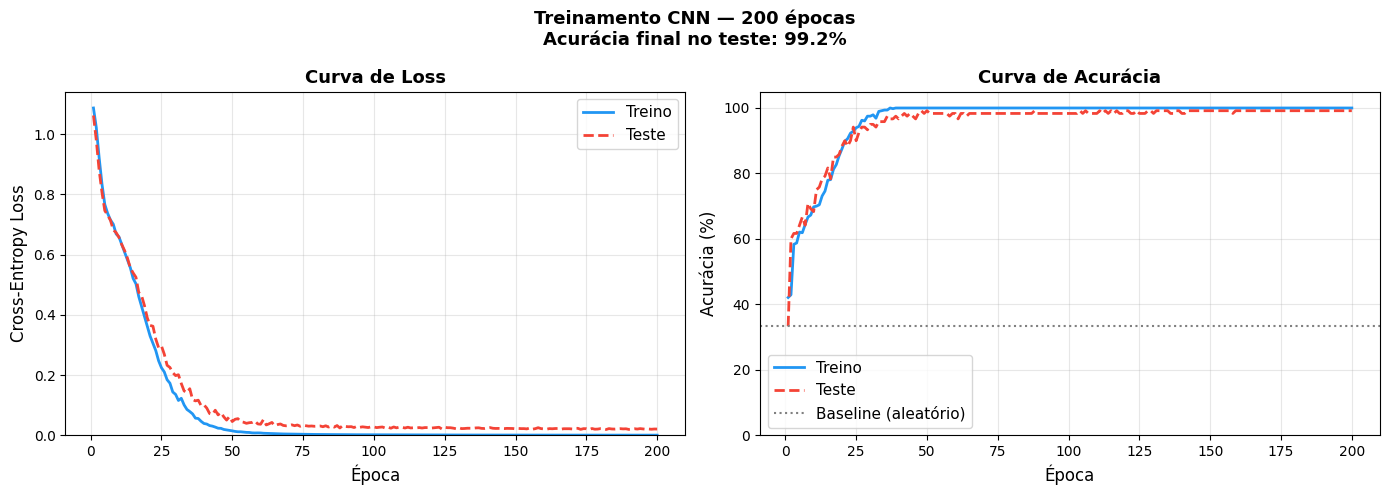

In [14]:
# Plotar curvas de loss e acurácia

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epocas = range(1, N_EPOCAS + 1)

# Loss
axes[0].plot(epocas, historico['loss_treino'], label='Treino', linewidth=2, color='#2196F3')
axes[0].plot(epocas, historico['loss_teste'], label='Teste', linewidth=2, color='#F44336', linestyle='--')
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[0].set_title('Curva de Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Acurácia
axes[1].plot(epocas, [a*100 for a in historico['acc_treino']],
             label='Treino', linewidth=2, color='#2196F3')
axes[1].plot(epocas, [a*100 for a in historico['acc_teste']],
             label='Teste', linewidth=2, color='#F44336', linestyle='--')
axes[1].axhline(100/3, color='gray', linestyle=':', label='Baseline (aleatório)')
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Acurácia (%)', fontsize=12)
axes[1].set_title('Curva de Acurácia', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 105)

plt.suptitle(f'Treinamento CNN — {N_EPOCAS} épocas\nAcurácia final no teste: {historico["acc_teste"][-1]:.1%}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


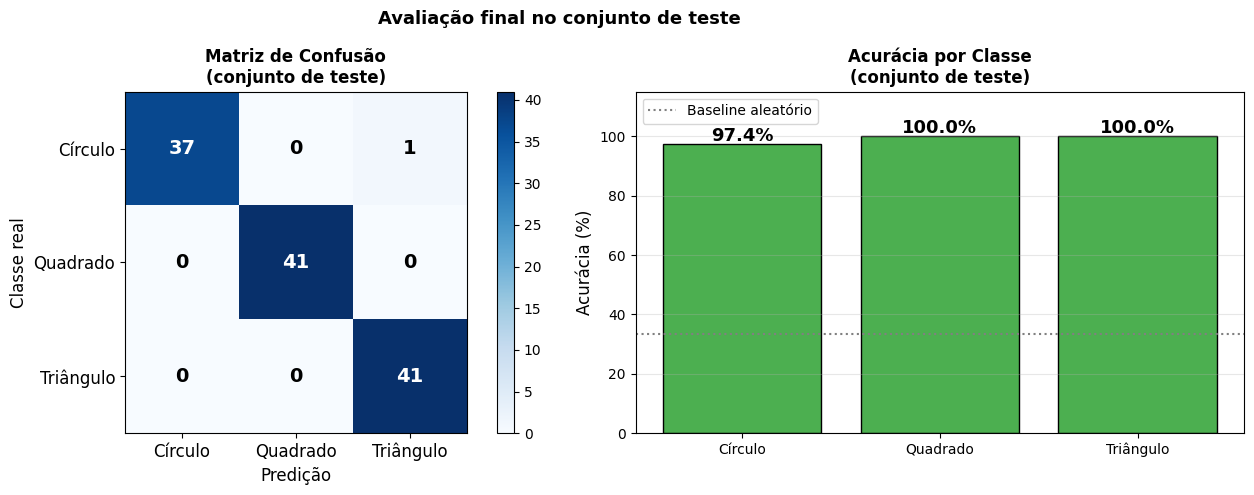

Acurácia por classe:
  Círculo     : 97.4%
  Quadrado    : 100.0%
  Triângulo   : 100.0%

Acurácia geral: 99.2%


In [15]:
# Matriz de confusão e acurácia por classe

modelo.eval()
with torch.no_grad():
    predicoes = modelo(X_teste_t).argmax(1).numpy()
    reais = y_teste_t.numpy()

nomes_classes = ['Círculo', 'Quadrado', 'Triângulo']

# Calcular matriz de confusão manualmente
n_classes = 3
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for real, pred in zip(reais, predicoes):
    conf_matrix[real, pred] += 1

# Plotar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
im = axes[0].imshow(conf_matrix, cmap='Blues')
axes[0].set_xticks(range(n_classes))
axes[0].set_yticks(range(n_classes))
axes[0].set_xticklabels(nomes_classes, fontsize=12)
axes[0].set_yticklabels(nomes_classes, fontsize=12)
axes[0].set_xlabel('Predição', fontsize=12)
axes[0].set_ylabel('Classe real', fontsize=12)
axes[0].set_title('Matriz de Confusão\n(conjunto de teste)', fontsize=12, fontweight='bold')

for i in range(n_classes):
    for j in range(n_classes):
        cor = 'white' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black'
        axes[0].text(j, i, str(conf_matrix[i, j]),
                     ha='center', va='center', fontsize=14, fontweight='bold', color=cor)

plt.colorbar(im, ax=axes[0])

# Acurácia por classe
accs_por_classe = [conf_matrix[i, i] / conf_matrix[i].sum() for i in range(n_classes)]
cores = ['#4CAF50' if a >= 0.9 else '#FF9800' if a >= 0.7 else '#F44336' for a in accs_por_classe]
barras = axes[1].bar(nomes_classes, [a*100 for a in accs_por_classe], color=cores, edgecolor='black')
for barra, acc in zip(barras, accs_por_classe):
    axes[1].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 1,
                 f'{acc:.1%}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Acurácia (%)', fontsize=12)
axes[1].set_title('Acurácia por Classe\n(conjunto de teste)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].axhline(100/3, color='gray', linestyle=':', label='Baseline aleatório')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Avaliação final no conjunto de teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Acurácia por classe:')
for nome, acc in zip(nomes_classes, accs_por_classe):
    print(f'  {nome:12s}: {acc:.1%}')
print(f'\nAcurácia geral: {(predicoes == reais).mean():.1%}')


> **A CNN nunca viu a definição de círculo, quadrado ou triângulo.**
> **Ela aprendeu que certos padrões de ativação de filtros correlacionam com certas labels.**
> **Isso é aprendizado. Não é compreensão.**

O modelo ajustou 1.281 números (os pesos) para minimizar o erro no conjunto de treino.
Não há nenhuma representação interna de "o que é um círculo" — há padrões de ativação que correlacionam com a label `0`.


## Parte 8 — Visualizando o que a CNN Aprendeu

A grande vantagem de usar dados sintéticos é que podemos inspecionar e entender tudo.
Vamos visualizar:
1. Os **filtros aprendidos** na primeira camada (e comparar com os filtros manuais da Parte 3)
2. Os **feature maps** — ativações intermediárias para cada classe
3. Um **Grad-CAM simplificado** — onde o modelo "olhou" para tomar a decisão


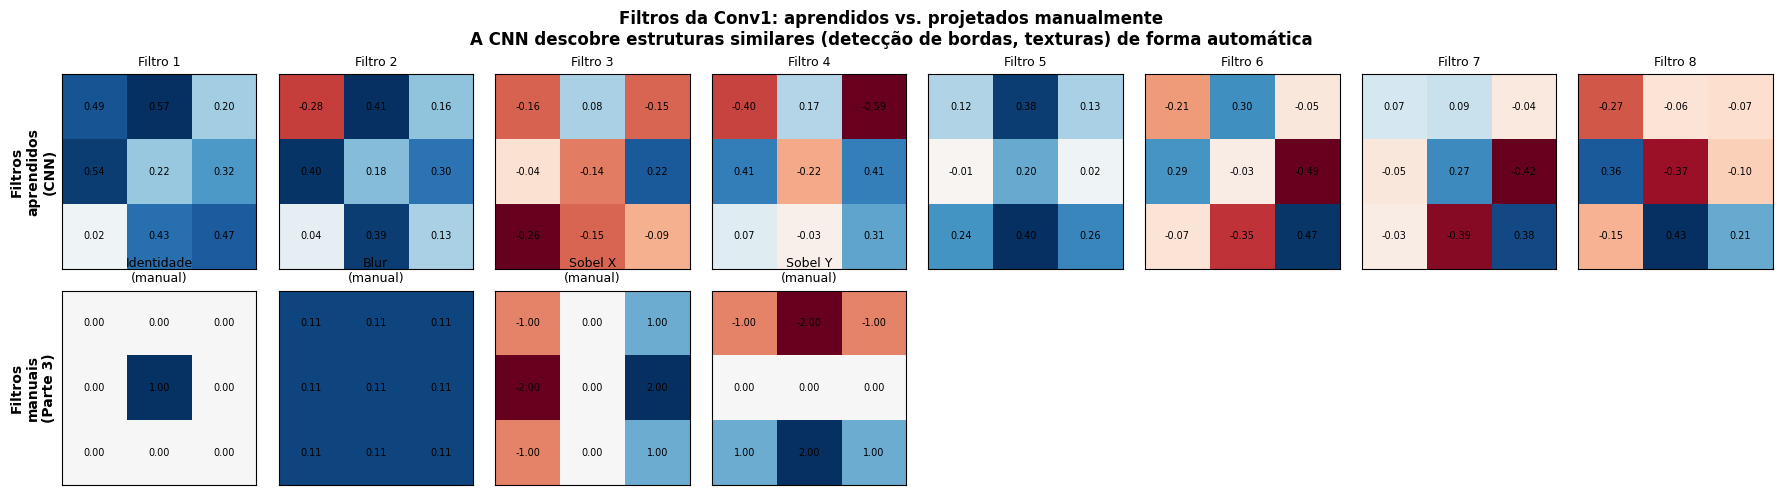

In [16]:
# === 8.1: Filtros da primeira camada ===

# Extrair os pesos da conv1: shape (8, 1, 3, 3)
# 8 filtros, 1 canal de entrada, 3×3 pixels
filtros_aprendidos = modelo.conv1.weight.data.numpy()  # (8, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))

# Linha 1: filtros aprendidos pela CNN
for i in range(8):
    filtro = filtros_aprendidos[i, 0]  # shape (3, 3)
    vmax = max(abs(filtro.min()), abs(filtro.max()))
    axes[0, i].imshow(filtro, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[0, i].set_title(f'Filtro {i+1}', fontsize=9)
    for r in range(3):
        for c in range(3):
            axes[0, i].text(c, r, f'{filtro[r,c]:.2f}',
                            ha='center', va='center', fontsize=7)
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

# Linha 2: filtros manuais para comparação (preenchendo com brancos os restantes)
filtros_manuais = [
    ('Identidade', filtro_identidade),
    ('Blur', filtro_blur),
    ('Sobel X', filtro_sobel_x),
    ('Sobel Y', filtro_sobel_y),
]
for i in range(8):
    if i < len(filtros_manuais):
        nome, filtro = filtros_manuais[i]
        vmax = max(abs(filtro.min()), abs(filtro.max())) + 0.01
        axes[1, i].imshow(filtro, cmap='RdBu', vmin=-vmax, vmax=vmax)
        axes[1, i].set_title(f'{nome}\n(manual)', fontsize=9)
        for r in range(3):
            for c in range(3):
                axes[1, i].text(c, r, f'{filtro[r,c]:.2f}',
                                ha='center', va='center', fontsize=7)
    else:
        axes[1, i].set_visible(False)
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

axes[0, 0].set_ylabel('Filtros\naprendidos\n(CNN)', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Filtros\nmanuais\n(Parte 3)', fontsize=10, fontweight='bold')

plt.suptitle('Filtros da Conv1: aprendidos vs. projetados manualmente\n'
             'A CNN descobre estruturas similares (detecção de bordas, texturas) de forma automática',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


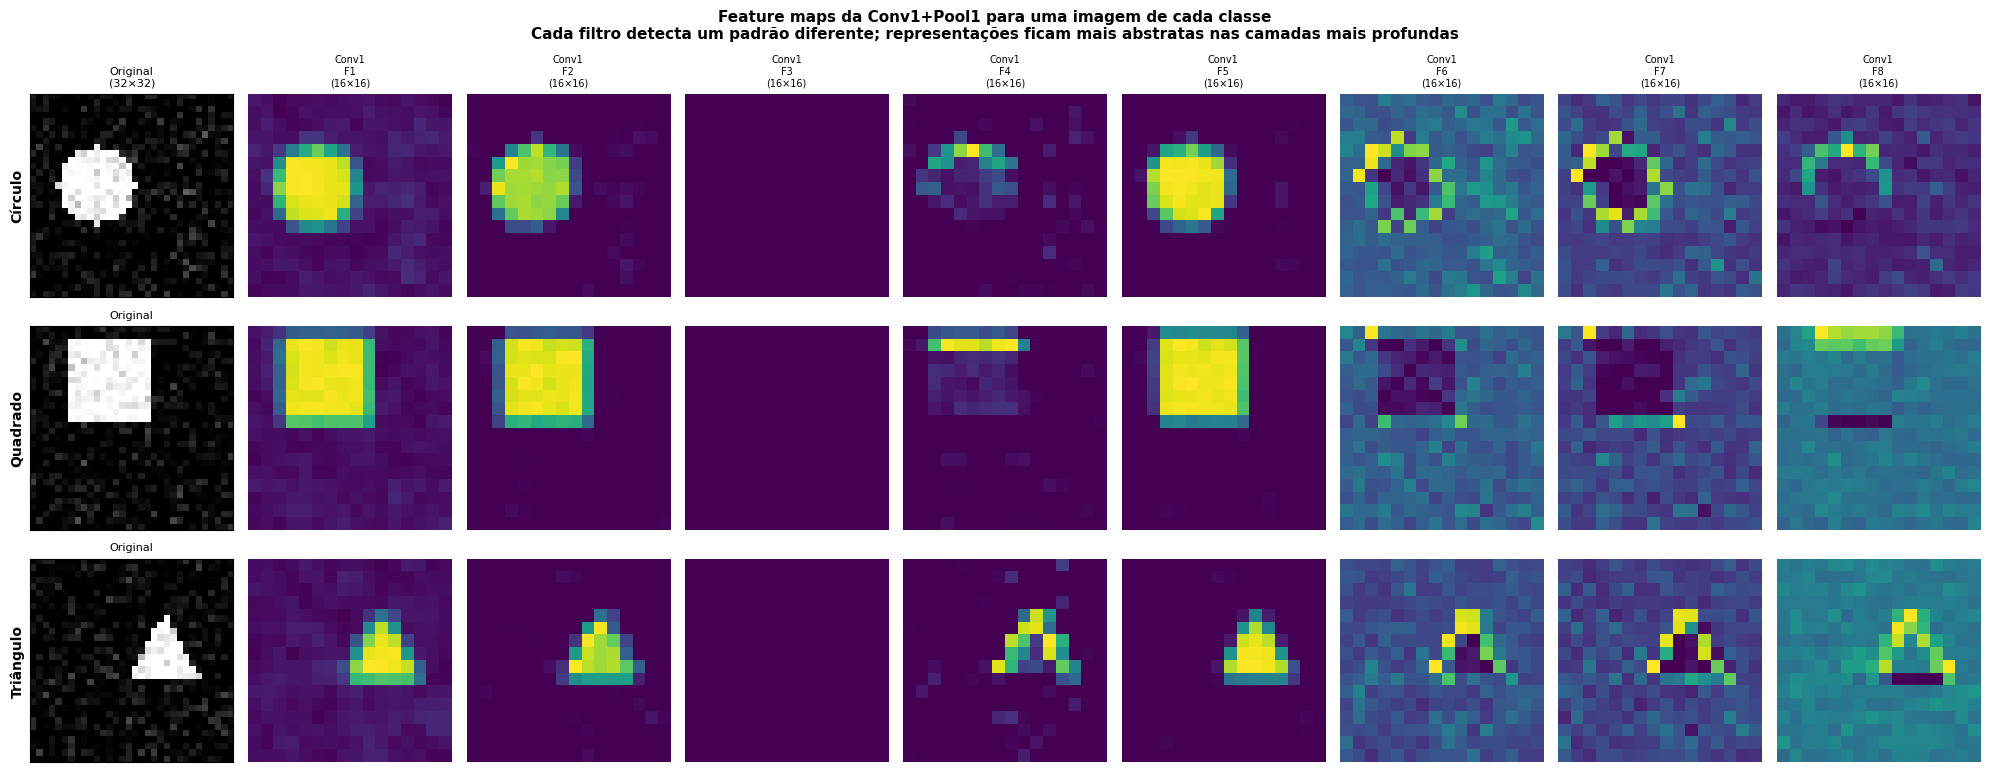

In [17]:
# === 8.2: Feature maps ===

# Para uma imagem de cada classe, mostrar as ativações de Conv1 e Conv2

# Selecionar um exemplo de cada classe do conjunto de teste
exemplos = {}
for classe in range(3):
    idx = np.where(y_teste == classe)[0][0]  # primeiro exemplo da classe
    exemplos[classe] = X_teste_t[idx:idx+1]  # shape (1, 1, 32, 32)

fig, axes = plt.subplots(3, 9, figsize=(20, 8))
nomes_classes_pt = ['Círculo', 'Quadrado', 'Triângulo']

modelo.eval()
with torch.no_grad():
    for linha, classe in enumerate(range(3)):
        x = exemplos[classe]
        
        # Imagem original
        axes[linha, 0].imshow(x[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[linha, 0].set_title('Original', fontsize=8)
        axes[linha, 0].axis('off')
        if linha == 0:
            axes[linha, 0].set_title('Original\n(32×32)', fontsize=8)
        axes[linha, 0].set_ylabel(nomes_classes_pt[classe], fontsize=10, fontweight='bold')
        axes[linha, 0].axis('on')
        axes[linha, 0].set_xticks([])
        axes[linha, 0].set_yticks([])
        
        # Feature maps da Conv1 (primeiros 8 filtros → 8 mapas 32×32)
        x_conv1 = modelo.pool1(modelo.relu1(modelo.conv1(x)))  # (1, 8, 16, 16)
        for f in range(8):
            fm = x_conv1[0, f].numpy()  # (16, 16)
            axes[linha, f+1].imshow(fm, cmap='viridis')
            if linha == 0:
                axes[linha, f+1].set_title(f'Conv1\nF{f+1}\n(16×16)', fontsize=7)
            axes[linha, f+1].axis('off')

plt.suptitle('Feature maps da Conv1+Pool1 para uma imagem de cada classe\n'
             'Cada filtro detecta um padrão diferente; representações ficam mais abstratas nas camadas mais profundas',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


/media/jdamicp/bkp/jdamico/dev/jupyter_env/lib/python3.13/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


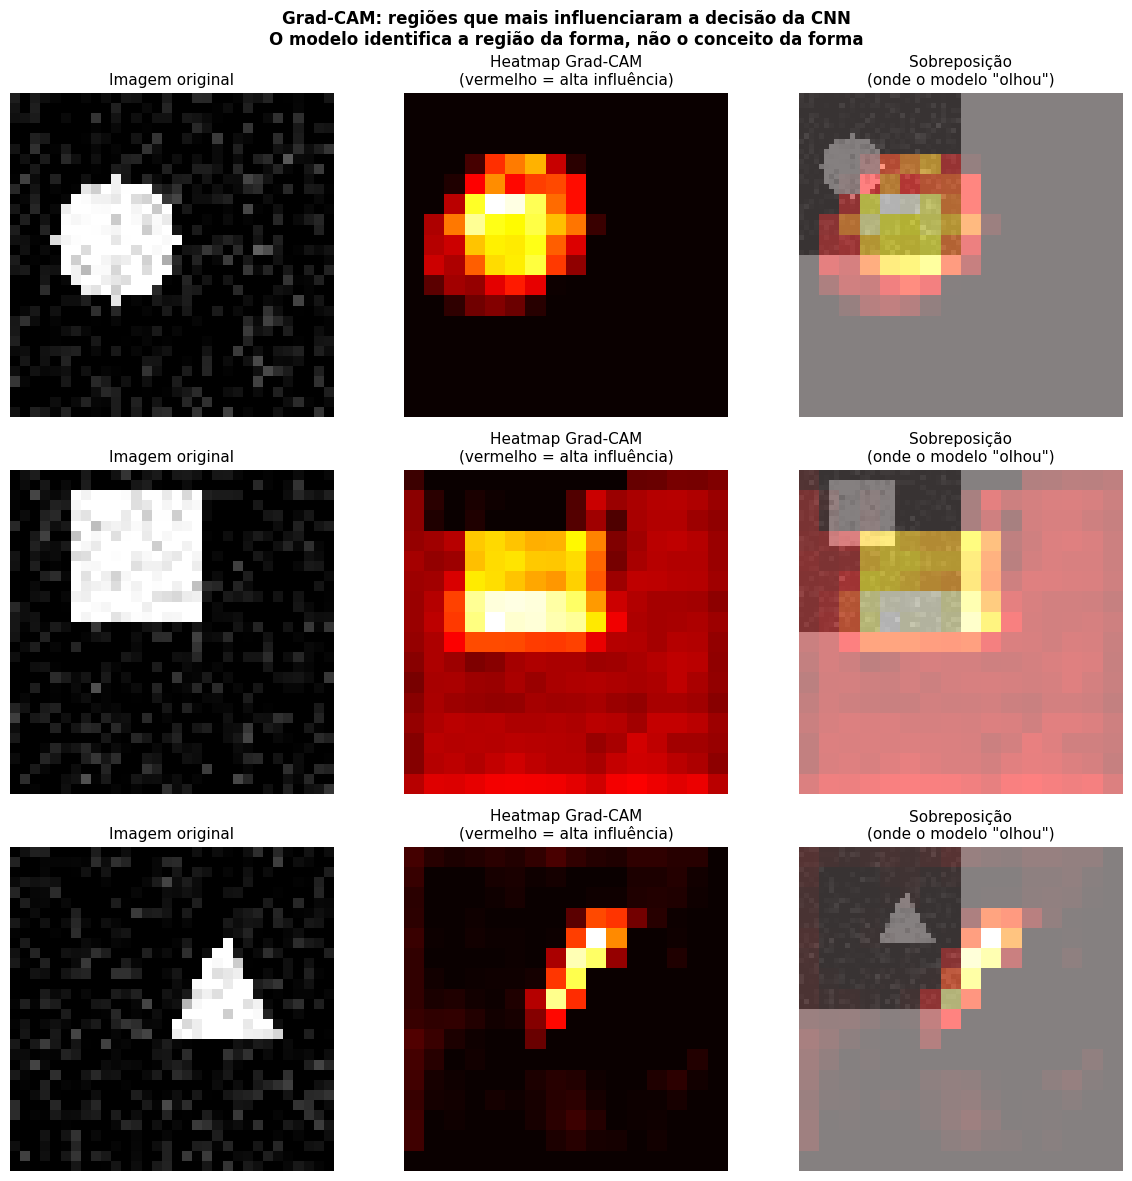

In [18]:
# === 8.3: Grad-CAM simplificado ===

# Grad-CAM: Gradient-weighted Class Activation Mapping
# Ideia: calcular o gradiente da pontuação da classe prevista
# em relação ao último feature map (saída da conv2).
# Regiões com gradiente alto são as que mais influenciaram a predição.

def grad_cam_simplificado(modelo, imagem_tensor, classe_alvo=None):
    """
    Grad-CAM simplificado: retorna heatmap de importância das regiões.
    
    Args:
        modelo: a CNN treinada
        imagem_tensor: tensor (1, 1, 32, 32)
        classe_alvo: classe para calcular o gradiente (None = classe predita)
    
    Returns:
        heatmap: array (32, 32) normalizado [0, 1]
        classe_pred: classe predita
    """
    modelo.eval()
    
    # Precisamos do gradiente em relação ao feature map da conv2
    # Usamos um 'hook' para capturar as ativações e gradientes
    ativacoes = {}  # armazenar ativações do forward pass
    gradientes = {}  # armazenar gradientes do backward pass
    
    def hook_forward(module, input, output):
        ativacoes['conv2'] = output.detach()
    
    def hook_backward(module, grad_input, grad_output):
        gradientes['conv2'] = grad_output[0].detach()
    
    # Registrar hooks na conv2
    handle_fwd = modelo.conv2.register_forward_hook(hook_forward)
    handle_bwd = modelo.conv2.register_backward_hook(hook_backward)
    
    # Forward pass com gradiente habilitado
    imagem_tensor = imagem_tensor.requires_grad_(True)
    logits = modelo(imagem_tensor)
    
    # Classe predita
    classe_pred = logits.argmax(1).item()
    if classe_alvo is None:
        classe_alvo = classe_pred
    
    # Backward apenas para a pontuação da classe alvo
    modelo.zero_grad()
    logits[0, classe_alvo].backward()
    
    # Remover hooks
    handle_fwd.remove()
    handle_bwd.remove()
    
    # Grad-CAM: média ponderada dos feature maps pelos gradientes globais médios
    # grad shape: (1, 16, 8, 8); ativ shape: (1, 16, 8, 8)
    pesos = gradientes['conv2'].mean(dim=[2, 3], keepdim=True)  # (1, 16, 1, 1)
    cam = (pesos * ativacoes['conv2']).sum(dim=1)[0]  # (8, 8)
    cam = torch.relu(cam)  # manter apenas ativações positivas
    cam = cam.numpy()
    
    # Normalizar para [0, 1]
    if cam.max() > 0:
        cam = cam / cam.max()
    
    # Redimensionar de 8×8 para 32×32 via repetição
    # np.repeat duplica cada elemento ao longo do eixo
    cam_32 = np.repeat(np.repeat(cam, 4, axis=0), 4, axis=1)  # 8→32
    
    return cam_32, classe_pred


# Visualizar Grad-CAM para um exemplo de cada classe
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
nomes_classes_pt = ['Círculo', 'Quadrado', 'Triângulo']

for linha, classe in enumerate(range(3)):
    x = exemplos[classe].clone()
    img_np = x[0, 0].numpy()  # (32, 32)
    
    heatmap, classe_pred = grad_cam_simplificado(modelo, x, classe_alvo=classe)
    
    # Col 0: imagem original
    axes[linha, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[linha, 0].set_title('Imagem original', fontsize=11)
    axes[linha, 0].set_ylabel(f'{nomes_classes_pt[classe]}\n(pred: {nomes_classes_pt[classe_pred]})',
                               fontsize=10, fontweight='bold')
    axes[linha, 0].axis('off')
    
    # Col 1: heatmap Grad-CAM
    axes[linha, 1].imshow(heatmap, cmap='hot', vmin=0, vmax=1)
    axes[linha, 1].set_title('Heatmap Grad-CAM\n(vermelho = alta influência)', fontsize=11)
    axes[linha, 1].axis('off')
    
    # Col 2: sobreposição
    axes[linha, 2].imshow(img_np, cmap='gray', vmin=0, vmax=1, alpha=0.6)
    axes[linha, 2].imshow(heatmap, cmap='hot', alpha=0.5, vmin=0, vmax=1)
    axes[linha, 2].set_title('Sobreposição\n(onde o modelo "olhou")', fontsize=11)
    axes[linha, 2].axis('off')

plt.suptitle('Grad-CAM: regiões que mais influenciaram a decisão da CNN\n'
             'O modelo identifica a região da forma, não o conceito da forma',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


> **A rede não 'olha' para o círculo como um humano olha.**
> **Ela identifica quais regiões do feature map mais influenciaram a predição.**
> **Isso parece similar, mas é mecanicamente diferente.**

O Grad-CAM mostra que a CNN foca nas bordas e na estrutura interna da forma — não porque "entende" geometria,
mas porque esses padrões de ativação correlacionaram com as labels corretas durante o treino.


## Parte 9 — De Classificação para Geração: O Processo de Difusão

Esta é a parte mais importante do notebook — vamos desmistificar **Veo, DALL-E e Stable Diffusion**.

A ideia-chave: esses modelos não foram programados para "desenhar" nada.
Eles aprendem a **remover ruído** de imagens. A geração emerge da inversão iterativa desse processo.

### O processo de difusão em duas etapas

**Processo forward (treino):** destruir progressivamente a imagem com ruído gaussiano
**Processo reverse (inferência):** aprender a inverter esse processo — remover o ruído

```
Forward:  x_0 (imagem real) → x_1 → x_2 → ... → x_T (ruído puro)
Reverse:  x_T (ruído puro)  → x_{T-1} → ... → x_1 → x_0 (imagem gerada)
```

O modelo aprende apenas o processo reverse — dado `x_t` e `t`, prever o ruído que foi adicionado.


### Parte 9a — O Processo Forward (Adição de Ruído)

O processo forward é definido matematicamente como:

$$q(x_t | x_0) = \mathcal{N}(\sqrt{\bar{\alpha}_t} \cdot x_0,\ (1 - \bar{\alpha}_t) \cdot I)$$

Onde:
- $\beta_t$ é o **noise schedule** — quanto ruído adicionamos no passo $t$
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ — produto acumulado
- $\sqrt{\bar{\alpha}_t}$ escala a imagem original (que vai para zero conforme $t$ aumenta)
- $(1 - \bar{\alpha}_t)$ é a variância do ruído (que vai para 1 conforme $t$ aumenta)

A propriedade chave: podemos calcular $x_t$ **diretamente** de $x_0$ sem iterar pelos passos intermediários.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

# Usar imagens 16x16 para o modelo de difusão treinar rápido em CPU
# (O processo é idêntico para imagens maiores — só mais lento)
TAMANHO_DIFF = 16
T_DIFF = 100  # número de passos de difusão

def computar_schedule(T=100, beta_min=0.0001, beta_max=0.02):
    """
    Calcula o noise schedule linear e os valores derivados.
    
    Schedule linear: beta aumenta linearmente de beta_min a beta_max.
    Isso é o schedule original do DDPM (Ho et al., 2020).
    """
    # beta_t cresce linearmente: menos ruído no início, mais no fim
    betas = np.linspace(beta_min, beta_max, T)  # shape: (T,)
    
    # alpha_t = 1 - beta_t
    alphas = 1.0 - betas  # shape: (T,)
    
    # alpha_barra_t = produto cumulativo de alpha_1 * alpha_2 * ... * alpha_t
    # np.cumprod calcula o produto acumulado
    alphas_barra = np.cumprod(alphas)  # shape: (T,)
    
    return betas, alphas, alphas_barra


def adicionar_ruido(imagem, t, alphas_barra):
    """
    Aplica o processo forward de difusão: adiciona ruído ao passo t.
    
    q(x_t | x_0) = sqrt(alpha_barra_t) * x_0 + sqrt(1 - alpha_barra_t) * epsilon
    
    onde epsilon ~ N(0, I) é ruído gaussiano padrão.
    
    Esta é a 'reparametrização' que permite calcular x_t diretamente de x_0.
    """
    # Coeficientes para o passo t (indexado de 0)
    sqrt_ab = np.sqrt(alphas_barra[t])        # escala da imagem original
    sqrt_1_ab = np.sqrt(1 - alphas_barra[t])  # escala do ruído
    
    # Amostrar ruído gaussiano padrão com mesma shape da imagem
    epsilon = np.random.normal(0, 1, imagem.shape)
    
    # Combinar imagem e ruído
    x_t = sqrt_ab * imagem + sqrt_1_ab * epsilon
    
    return x_t, epsilon


# Computar schedule com beta_max=0.08 para destruição completa em T=100 passos
betas, alphas, alphas_barra = computar_schedule(T=T_DIFF, beta_min=0.0001, beta_max=0.08)

print('Noise schedule (primeiros 10 e últimos 5 valores):')
print(f'  beta (primeiros 5):        {betas[:5]}')
print(f'  beta (últimos 5):          {betas[-5:]}')
print(f'  alpha_barra (primeiros 5): {alphas_barra[:5].round(4)}')
print(f'  alpha_barra (últimos 5):   {alphas_barra[-5:].round(4)}')
print()
print(f'alpha_barra no passo final (t={T_DIFF-1}): {alphas_barra[-1]:.6f}')
print('→ No passo T, quase nada da imagem original resta (alpha_barra ≈ 0)')

Noise schedule (primeiros 10 e últimos 5 valores):
  beta (primeiros 5):        [0.0001     0.00090707 0.00171414 0.00252121 0.00332828]
  beta (últimos 5):          [0.07677172 0.07757879 0.07838586 0.07919293 0.08      ]
  alpha_barra (primeiros 5): [0.9999 0.999  0.9973 0.9948 0.9915]
  alpha_barra (últimos 5):   [0.0226 0.0209 0.0192 0.0177 0.0163]

alpha_barra no passo final (t=99): 0.016295
→ No passo T, quase nada da imagem original resta (alpha_barra ≈ 0)


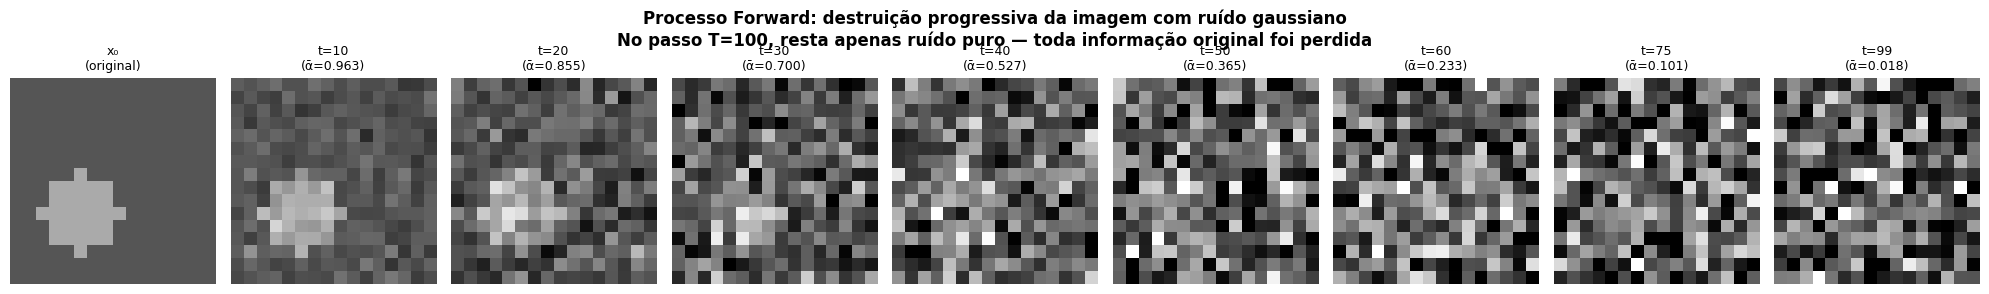

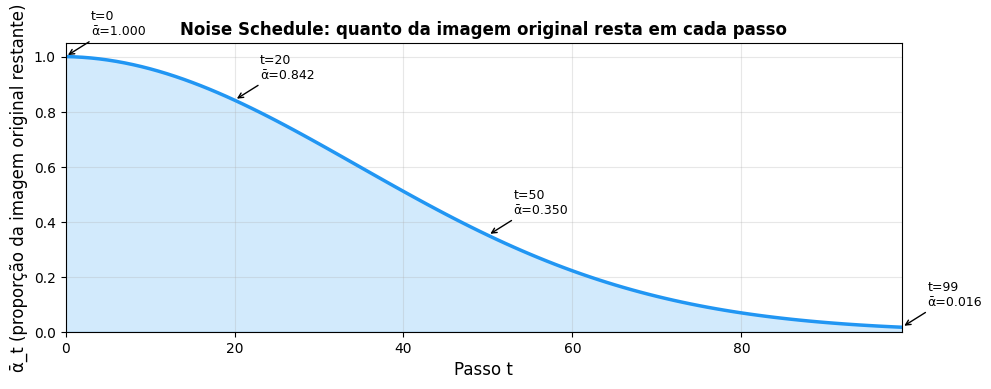

Processo forward: pegamos uma imagem real e a destruímos progressivamente.
No passo T, o que sobra é ruído puro — sem nenhuma informação da imagem original.


In [20]:
# Visualizar o processo forward

# Gerar uma imagem de círculo 16x16
def criar_circulo_16(seed=0):
    rng = np.random.RandomState(seed)
    tamanho = TAMANHO_DIFF
    raio = rng.randint(3, 6)
    margem = raio + 1
    cx = rng.randint(margem, tamanho - margem)
    cy = rng.randint(margem, tamanho - margem)
    y, x = np.ogrid[:tamanho, :tamanho]
    mascara = (x - cx)**2 + (y - cy)**2 <= raio**2
    imagem = mascara.astype(np.float32)
    return imagem

img_original = criar_circulo_16(seed=7)

# Plotar processo forward em 9 passos
passos_plot = [0, 10, 20, 30, 40, 50, 60, 75, 99]

fig, axes = plt.subplots(1, 9, figsize=(20, 3))

np.random.seed(42)
for i, t in enumerate(passos_plot):
    if t == 0:
        img_plot = img_original
        titulo = 'x₀\n(original)'
    else:
        img_ruidosa, _ = adicionar_ruido(img_original, t-1, alphas_barra)
        img_plot = img_ruidosa
        ab = alphas_barra[t-1]
        titulo = f't={t}\n(ᾱ={ab:.3f})'
    
    axes[i].imshow(img_plot, cmap='gray', vmin=-1, vmax=2)
    axes[i].set_title(titulo, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Processo Forward: destruição progressiva da imagem com ruído gaussiano\n'
             'No passo T=100, resta apenas ruído puro — toda informação original foi perdida',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar como alpha_barra decai
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(T_DIFF), alphas_barra, color='#2196F3', linewidth=2.5)
ax.fill_between(range(T_DIFF), alphas_barra, alpha=0.2, color='#2196F3')
ax.set_xlabel('Passo t', fontsize=12)
ax.set_ylabel('ᾱ_t (proporção da imagem original restante)', fontsize=12)
ax.set_title('Noise Schedule: quanto da imagem original resta em cada passo', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, T_DIFF-1)
ax.set_ylim(0, 1.05)

# Anotar pontos-chave
for t in [0, 20, 50, 99]:
    ax.annotate(f't={t}\nᾱ={alphas_barra[t]:.3f}',
                xy=(t, alphas_barra[t]),
                xytext=(t+3, alphas_barra[t]+0.08),
                fontsize=9,
                arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print('Processo forward: pegamos uma imagem real e a destruímos progressivamente.')
print('No passo T, o que sobra é ruído puro — sem nenhuma informação da imagem original.')

### Parte 9b — O que o Modelo de Difusão Aprende

O modelo de difusão aprende uma única tarefa:

> Dado uma imagem ruidosa $x_t$ e o timestep $t$, prever o ruído $\epsilon$ que foi adicionado.

A função objetivo é simples — **erro quadrático médio** entre o ruído predito e o ruído real:

$$\mathcal{L} = \mathbb{E}_{x_0, t, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$$

O modelo não sabe que está "gerando imagens". Ele está apenas minimizando um MSE de previsão de ruído.

Usamos um **MLP simples** (Multi-Layer Perceptron) como denoiser. Em modelos reais (DALL-E, Stable Diffusion),
o denoiser é uma U-Net com atenção — mas o princípio é idêntico.


In [21]:
# Denoiser simples: MLP com embedding de timestep

class DenoisingMLP(nn.Module):
    """
    MLP simples para denoising difusion.
    
    Input:  imagem ruidosa x_t (flattened: 16×16 = 256 valores)
            + embedding do timestep t (64 valores)
    Output: ruído predito epsilon_theta (256 val10ores, mesma shape do input)
    
    Nota: modelos reais usam U-Net com atenção. O princípio é o mesmo.
    """
    def __init__(self, img_size=16, T=50, embed_dim=64, hidden=512):
        super().__init__()
        self.img_size = img_size
        self.img_pixels = img_size * img_size  # 256
        self.T = T
        
        # Embedding para o timestep: converte inteiro t em vetor de tamanho embed_dim
        # Isso informa ao modelo 'em que ponto do processo de difusão estamos'
        self.time_embed = nn.Embedding(T, embed_dim)
        
        # Rede principal: recebe imagem + embedding de tempo
        # Input: 256 (imagem) + 64 (tempo) = 320 valores
        input_dim = self.img_pixels + embed_dim
        
        self.rede = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            # Saída: predição do ruído (mesma dimensão da imagem)
            nn.Linear(hidden // 2, self.img_pixels)
        )
    
    def forward(self, x_t, t):
        """
        Args:
            x_t: tensor (batch, 256) — imagem ruidosa flattened
            t:   tensor (batch,)   — timestep (inteiro 0..T-1)
        Returns:
            epsilon_pred: tensor (batch, 256) — ruído predito
        """
        # Embedding do timestep: (batch,) → (batch, embed_dim)
        t_emb = self.time_embed(t)
        
        # Concatenar imagem e embedding de tempo
        entrada = torch.cat([x_t, t_emb], dim=1)  # (batch, 256+64)
        
        # Prever o ruído
        return self.rede(entrada)


denoiser = DenoisingMLP(img_size=TAMANHO_DIFF, T=T_DIFF)

# Contar parâmetros
total_params = sum(p.numel() for p in denoiser.parameters())
print(f'Denoiser MLP — total de parâmetros: {total_params:,}')
print()
print(denoiser)


Denoiser MLP — total de parâmetros: 630,528

DenoisingMLP(
  (time_embed): Embedding(100, 64)
  (rede): Sequential(
    (0): Linear(in_features=320, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
  )
)


Dataset de difusão: (5000, 16, 16)  (N=500 imagens 16×16, valores em [-1,1])
Min: -1.00, Max: 1.00

Treinando denoiser — 300 épocas...
Época  75/300 | Loss MSE: 0.4688 | Tempo: 151.0s
Época 150/300 | Loss MSE: 0.4701 | Tempo: 302.5s
Época 225/300 | Loss MSE: 0.5014 | Tempo: 490.9s
Época 300/300 | Loss MSE: 0.4722 | Tempo: 620.0s
Treinamento concluído em 620.0s


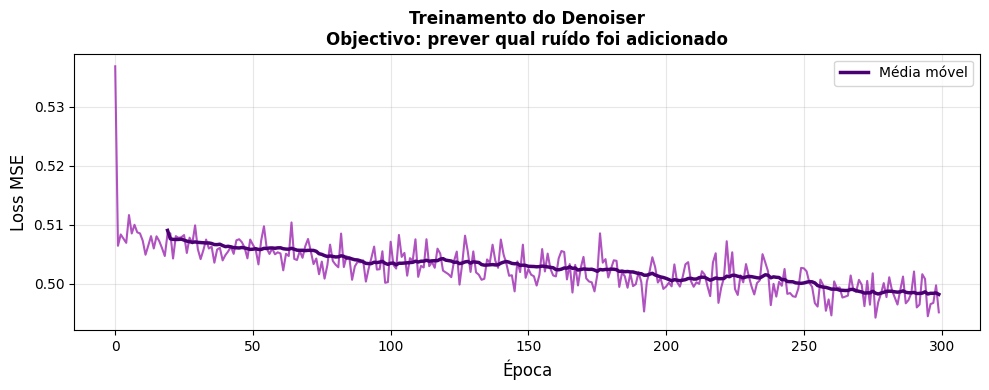

In [23]:
# ============================================================
# Gerar dataset de treinamento para o denoiser
# ============================================================

# Vamos gerar apenas círculos 16×16 para o modelo de difusão
# (para manter o treino rápido em CPU)

N_DIFF = 5000  # 5000 imagens de círculos 16×16

def gerar_circulo_16x16(seed=None):
    rng = np.random.RandomState(seed)
    tamanho = TAMANHO_DIFF
    raio = rng.randint(3, 6)
    margem = raio + 1
    cx = rng.randint(margem, tamanho - margem)
    cy = rng.randint(margem, tamanho - margem)
    y, x = np.ogrid[:tamanho, :tamanho]
    mascara = (x - cx)**2 + (y - cy)**2 <= raio**2
    # Normalizar para [-1, 1] (convenção do DDPM original)
    imagem = mascara.astype(np.float32) * 2.0 - 1.0
    return imagem

imagens_diff = np.array([gerar_circulo_16x16(seed=i) for i in range(N_DIFF)])
print(f'Dataset de difusão: {imagens_diff.shape}  (N=500 imagens 16×16, valores em [-1,1])')
print(f'Min: {imagens_diff.min():.2f}, Max: {imagens_diff.max():.2f}')


# Loop de treinamento do denoiser
import time

torch.manual_seed(42)
np.random.seed(42)

otimizador_diff = torch.optim.Adam(denoiser.parameters(), lr=1e-3)
criterio_diff = nn.MSELoss()

N_EPOCAS_DIFF = 300
BATCH_DIFF = 64
historico_diff = []

imagens_tensor = torch.tensor(imagens_diff, dtype=torch.float32)  # (500, 16, 16)

t0 = time.time()
print(f'\nTreinando denoiser — {N_EPOCAS_DIFF} épocas...')
print('=' * 55)

for epoca in range(N_EPOCAS_DIFF):
    denoiser.train()
    
    indices = np.random.permutation(N_DIFF)
    losses_epoca = []
    
    for inicio in range(0, N_DIFF, BATCH_DIFF):
        idx = indices[inicio:inicio+BATCH_DIFF]
        x0_batch = imagens_tensor[idx]
        batch_atual = x0_batch.shape[0]
        
        t_batch = torch.randint(0, T_DIFF, (batch_atual,))
        epsilon = torch.randn_like(x0_batch)
        
        ab = torch.tensor(alphas_barra[t_batch.numpy()], dtype=torch.float32)
        sqrt_ab = torch.sqrt(ab).view(-1, 1, 1)
        sqrt_1_ab = torch.sqrt(1 - ab).view(-1, 1, 1)
        x_t = sqrt_ab * x0_batch + sqrt_1_ab * epsilon
        
        x_t_flat = x_t.view(batch_atual, -1)
        epsilon_flat = epsilon.view(batch_atual, -1)
        
        otimizador_diff.zero_grad()
        epsilon_pred = denoiser(x_t_flat, t_batch)
        loss = criterio_diff(epsilon_pred, epsilon_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(denoiser.parameters(), 1.0)
        otimizador_diff.step()
        
        losses_epoca.append(loss.item())
    
    historico_diff.append(np.mean(losses_epoca))
    
    if (epoca + 1) % 75 == 0:
        print(f'Época {epoca+1:3d}/{N_EPOCAS_DIFF} | Loss MSE: {loss.item():.4f} | Tempo: {time.time()-t0:.1f}s')

print('=' * 55)
print(f'Treinamento concluído em {time.time()-t0:.1f}s')

# Plotar curva de loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico_diff, linewidth=1.5, color='#9C27B0', alpha=0.8)
# Suavizar com média móvel
janela = 20
loss_suave = np.convolve(historico_diff, np.ones(janela)/janela, mode='valid')
ax.plot(range(janela-1, len(historico_diff)), loss_suave, linewidth=2.5, color='#4A0072', label='Média móvel')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Loss MSE', fontsize=12)
ax.set_title('Treinamento do Denoiser\nObjectivo: prever qual ruído foi adicionado', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Parte 9c — O Processo Reverse (Geração)

Com o denoiser treinado, podemos amostrar novas imagens:

1. Começar com ruído puro $x_T \sim \mathcal{N}(0, I)$
2. Em cada passo $t = T, T-1, ..., 1$:
   - Usar o denoiser para prever $\hat{\epsilon} = \epsilon_\theta(x_t, t)$
   - Remover o ruído predito usando a fórmula DDPM
   - Adicionar ruído menor (exceto no último passo)
3. $x_0$ é a imagem gerada

A fórmula de update DDPM:
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\hat{\epsilon}\right) + \sigma_t z$$

onde $z \sim \mathcal{N}(0,I)$ e $\sigma_t = \sqrt{\beta_t}$.


Gerando imagens de círculos via processo reverse...
Geradas 12 imagens


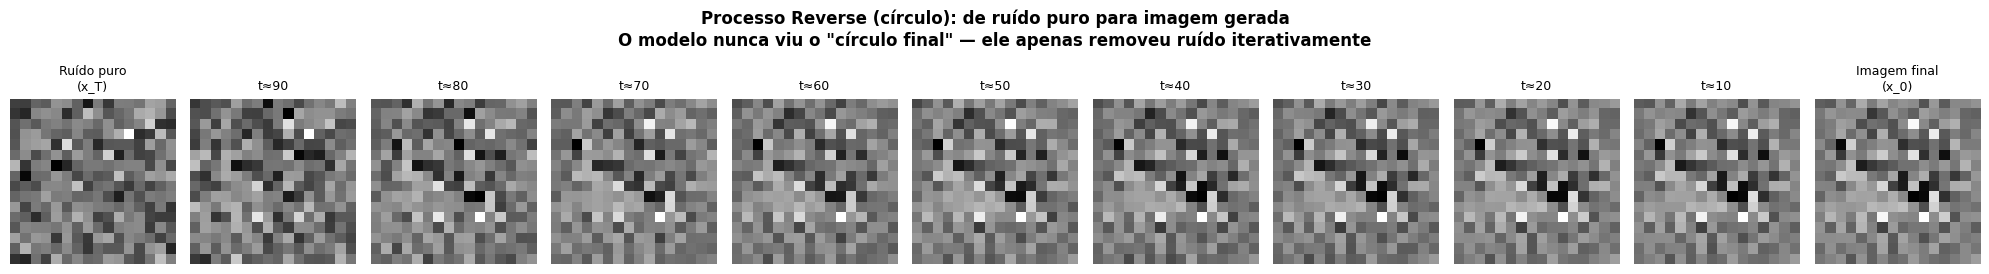

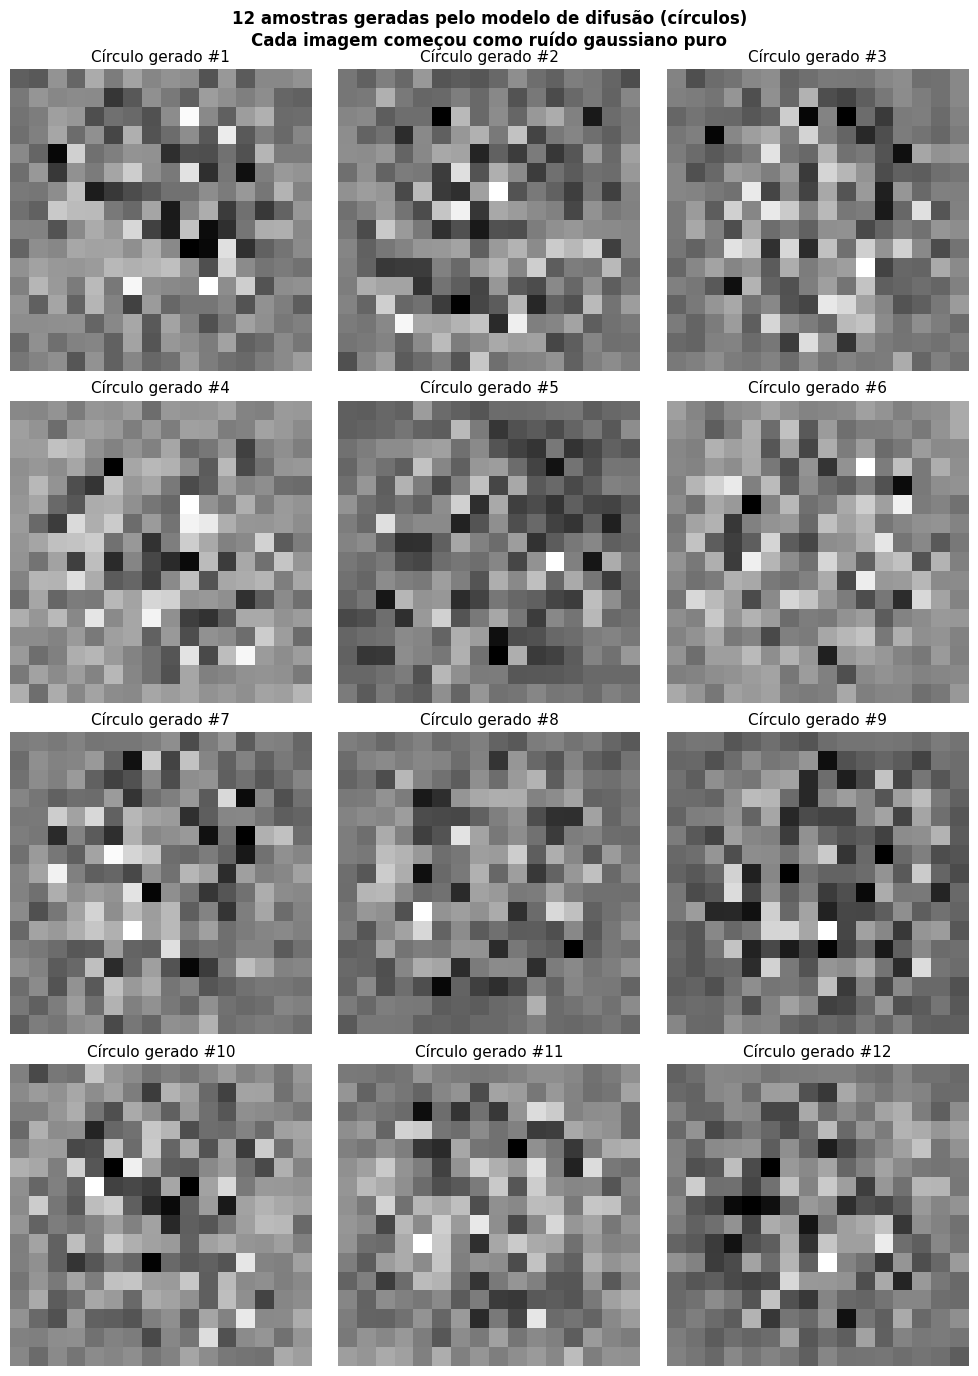

O modelo nunca foi programado para desenhar um círculo.
Ele foi treinado para uma única tarefa: dado x_t e t, prever qual ruído foi adicionado.
A geração emerge da inversão iterativa desse processo.


In [24]:
def gerar_imagem_diff(modelo, T=100, betas=None, alphas=None, alphas_barra=None,
                       img_size=16, seed=None):
    """
    Processo reverse de difusão: gera uma imagem a partir de ruído puro.
    
    1. Começa com x_T ~ N(0, I)
    2. Para t de T-1 até 0:
       a. Prever ruído: epsilon_pred = modelo(x_t, t)
       b. Calcular x_{t-1} usando fórmula DDPM
       c. Adicionar ruído sigma_t * z (exceto no último passo)
    3. Retornar x_0
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    modelo.eval()
    n_pixels = img_size * img_size
    
    # Passo 1: começar com ruído puro x_T ~ N(0, I)
    x = torch.randn(1, n_pixels)
    
    # Guardar trajetória para visualização
    trajetoria = [x.view(img_size, img_size).detach().numpy().copy()]
    
    with torch.no_grad():
        # Passo 2: iterar de T-1 até 0 (processo reverse)
        for t in reversed(range(T)):
            # Timestep como tensor
            t_tensor = torch.tensor([t], dtype=torch.long)
            
            # a. Prever ruído
            epsilon_pred = modelo(x, t_tensor)
            
            # b. Extrair os coeficientes para o passo t
            beta_t = float(betas[t])
            alpha_t = float(alphas[t])
            ab_t = float(alphas_barra[t])
            
            # Coeficiente para remover o ruído predito
            # (1 - alpha_t) / sqrt(1 - alpha_barra_t)
            coef_epsilon = (1 - alpha_t) / np.sqrt(1 - ab_t)
            
            # Fórmula DDPM: x_{t-1} = (1/sqrt(alpha_t)) * (x_t - coef * epsilon_pred)
            x_prev = (1.0 / np.sqrt(alpha_t)) * (x - coef_epsilon * epsilon_pred)
            
            # c. Adicionar ruído sigma_t * z (exceto no último passo t=0)
            if t > 0:
                sigma_t = np.sqrt(beta_t)  # desvio padrão do ruído adicionado
                z = torch.randn_like(x)    # z ~ N(0, I)
                x_prev = x_prev + sigma_t * z
            
            x = x_prev
            
            # Guardar frames para visualização (a cada 10 passos)
            if t % 10 == 0 or t == 0:
                trajetoria.append(x.view(img_size, img_size).detach().numpy().copy())
    
    return x.view(img_size, img_size).detach().numpy(), trajetoria


# Gerar 12 imagens de círculos e mostrar trajetória para a primeira
print('Gerando imagens de círculos via processo reverse...')

imagens_geradas_circulo = []
for s in range(12):
    img, traj = gerar_imagem_diff(denoiser, T=T_DIFF, betas=betas, alphas=alphas,
                                   alphas_barra=alphas_barra, img_size=TAMANHO_DIFF, seed=s)
    imagens_geradas_circulo.append(img)

print(f'Geradas {len(imagens_geradas_circulo)} imagens')

# Visualizar trajetória da primeira imagem gerada
_, trajetoria = gerar_imagem_diff(denoiser, T=T_DIFF, betas=betas, alphas=alphas,
                                   alphas_barra=alphas_barra, img_size=TAMANHO_DIFF, seed=0)

fig, axes = plt.subplots(1, len(trajetoria), figsize=(20, 3))
for i, (ax, frame) in enumerate(zip(axes, trajetoria)):
    ax.imshow(frame, cmap='gray')
    if i == 0:
        ax.set_title(f'Ruído puro\n(x_T)', fontsize=9)
    elif i == len(trajetoria) - 1:
        ax.set_title(f'Imagem final\n(x_0)', fontsize=9)
    else:
        t_val = T_DIFF - i * 10
        ax.set_title(f't≈{t_val}', fontsize=9)
    ax.axis('off')

plt.suptitle('Processo Reverse (círculo): de ruído puro para imagem gerada\n'
             'O modelo nunca viu o "círculo final" — ele apenas removeu ruído iterativamente',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar as 12 imagens geradas
fig, axes = plt.subplots(4, 3, figsize=(10, 14))
for i, (ax, img) in enumerate(zip(axes.flat, imagens_geradas_circulo)):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Círculo gerado #{i+1}', fontsize=11)
    ax.axis('off')

plt.suptitle('12 amostras geradas pelo modelo de difusão (círculos)\n'
             'Cada imagem começou como ruído gaussiano puro',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('O modelo nunca foi programado para desenhar um círculo.')
print('Ele foi treinado para uma única tarefa: dado x_t e t, prever qual ruído foi adicionado.')
print('A geração emerge da inversão iterativa desse processo.')

### Parte 9d — Difusão para Triângulos

O mesmo pipeline funciona para qualquer distribuição de imagens. Agora treinamos um segundo denoiser — com **exatamente os mesmos hiperparâmetros** — mas desta vez o dataset é composto de triângulos isósceles.

**Ponto central:** o modelo não sabe que é "triângulo". Ele aprende a distribuição estatística dos pixels dos triângulos da mesma forma que aprendeu a dos círculos — removendo ruído iterativamente.

Dataset de triângulos: (5000, 16, 16)  (N=5000 imagens 16×16, valores em [-1,1])
Min: -1.00, Max: 1.00


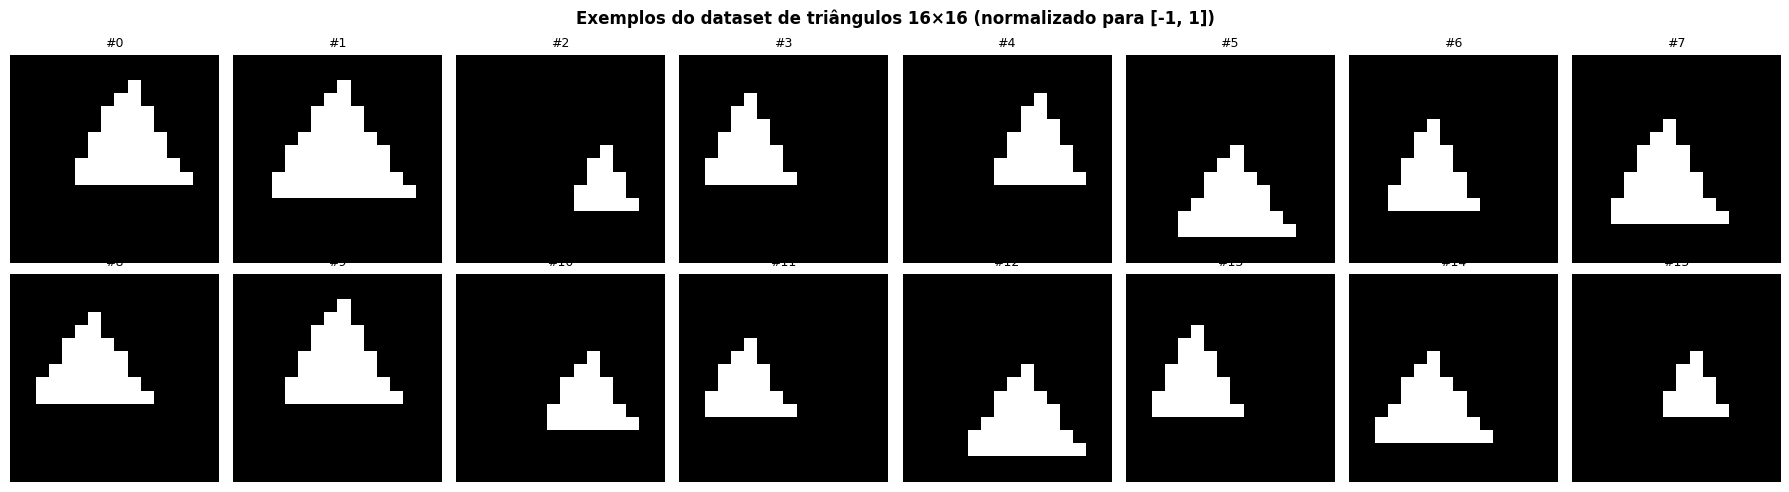

In [25]:
# ============================================================
# Gerador de triângulos 16×16 para o modelo de difusão
# ============================================================

def gerar_triangulo_16x16(seed=None):
    """
    Gera imagem 16×16 com um triângulo isósceles preenchido.
    
    Usa o mesmo algoritmo de rasterização scanline do gerar_triangulo() da Parte 5,
    adaptado para o tamanho 16×16 e normalizado para [-1, 1] (convenção DDPM).
    """
    rng = np.random.RandomState(seed)
    tamanho = TAMANHO_DIFF  # 16
    
    # Sortear base entre 5 e 10 pixels (proporcional ao tamanho 16×16)
    base = rng.randint(5, 11)
    altura = max(int(base * 0.866), 4)  # h = b * sqrt(3)/2, mínimo 4px
    
    margem = 2
    cx = rng.randint(base // 2 + margem, tamanho - base // 2 - margem)
    y_base = rng.randint(altura + margem, tamanho - margem)
    y_topo = y_base - altura
    
    # Vértices: topo (centro), base-esquerda, base-direita
    v_topo = (cx, y_topo)
    v_esq  = (cx - base // 2, y_base)
    v_dir  = (cx + base // 2, y_base)
    
    imagem = np.zeros((tamanho, tamanho), dtype=np.float32)
    
    # Rasterização por varredura de linhas (scanline rendering)
    for y in range(max(0, y_topo), min(tamanho, y_base + 1)):
        if y_base == y_topo:
            continue
        t = (y - y_topo) / (y_base - y_topo)
        x_esq = v_topo[0] + t * (v_esq[0] - v_topo[0])
        x_dir = v_topo[0] + t * (v_dir[0] - v_topo[0])
        x_ini = max(0, int(x_esq))
        x_fim = min(tamanho, int(x_dir) + 1)
        imagem[y, x_ini:x_fim] = 1.0
    
    # Normalizar para [-1, 1] (convenção DDPM)
    imagem = imagem * 2.0 - 1.0
    return imagem


# Gerar dataset de triângulos
N_DIFF_TRI = 5000

imagens_triangulo = np.array([gerar_triangulo_16x16(seed=i) for i in range(N_DIFF_TRI)])
print(f'Dataset de triângulos: {imagens_triangulo.shape}  (N={N_DIFF_TRI} imagens 16×16, valores em [-1,1])')
print(f'Min: {imagens_triangulo.min():.2f}, Max: {imagens_triangulo.max():.2f}')

# Visualizar alguns exemplos do dataset
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagens_triangulo[i], cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'#{i}', fontsize=9)
    ax.axis('off')
plt.suptitle('Exemplos do dataset de triângulos 16×16 (normalizado para [-1, 1])',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Treinando denoiser para triângulos — 300 épocas...
Época  75/300 | Loss MSE: 0.3826 | Tempo: 267.2s
Época 150/300 | Loss MSE: 0.4386 | Tempo: 568.4s
Época 225/300 | Loss MSE: 0.5608 | Tempo: 843.2s
Época 300/300 | Loss MSE: 0.4467 | Tempo: 1148.5s
Treinamento concluído em 1148.5s


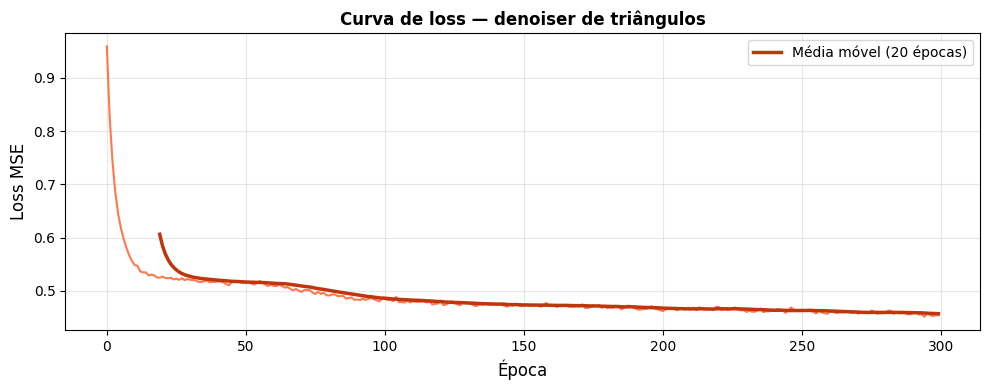

In [26]:
# ============================================================
# Treinar denoiser para triângulos
# Mesmos hiperparâmetros usados para círculos
# ============================================================

torch.manual_seed(42)
np.random.seed(42)

# Criar novo denoiser (mesma arquitetura do círculo)
denoiser_triangulo = DenoisingMLP(img_size=TAMANHO_DIFF, T=T_DIFF)

otimizador_tri = torch.optim.Adam(denoiser_triangulo.parameters(), lr=1e-3)
criterio_tri   = nn.MSELoss()

N_EPOCAS_TRI = 300
BATCH_TRI    = 64
historico_tri = []

imagens_tri_tensor = torch.tensor(imagens_triangulo, dtype=torch.float32)

t0 = time.time()
print(f'Treinando denoiser para triângulos — {N_EPOCAS_TRI} épocas...')
print('=' * 55)

for epoca in range(N_EPOCAS_TRI):
    denoiser_triangulo.train()
    
    indices = np.random.permutation(N_DIFF_TRI)
    losses_epoca = []
    
    for inicio in range(0, N_DIFF_TRI, BATCH_TRI):
        idx = indices[inicio:inicio+BATCH_TRI]
        x0_batch = imagens_tri_tensor[idx]
        batch_atual = x0_batch.shape[0]
        
        t_batch = torch.randint(0, T_DIFF, (batch_atual,))
        epsilon  = torch.randn_like(x0_batch)
        
        ab = torch.tensor(alphas_barra[t_batch.numpy()], dtype=torch.float32)
        sqrt_ab   = torch.sqrt(ab).view(-1, 1, 1)
        sqrt_1_ab = torch.sqrt(1 - ab).view(-1, 1, 1)
        x_t = sqrt_ab * x0_batch + sqrt_1_ab * epsilon
        
        x_t_flat      = x_t.view(batch_atual, -1)
        epsilon_flat   = epsilon.view(batch_atual, -1)
        
        otimizador_tri.zero_grad()
        epsilon_pred = denoiser_triangulo(x_t_flat, t_batch)
        loss = criterio_tri(epsilon_pred, epsilon_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(denoiser_triangulo.parameters(), 1.0)
        otimizador_tri.step()
        
        losses_epoca.append(loss.item())
    
    historico_tri.append(np.mean(losses_epoca))
    
    if (epoca + 1) % 75 == 0:
        print(f'Época {epoca+1:3d}/{N_EPOCAS_TRI} | Loss MSE: {loss.item():.4f} | Tempo: {time.time()-t0:.1f}s')

print('=' * 55)
print(f'Treinamento concluído em {time.time()-t0:.1f}s')

# Curva de loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico_tri, linewidth=1.5, color='#FF5722', alpha=0.8)
janela = 20
media_movel = np.convolve(historico_tri, np.ones(janela)/janela, mode='valid')
ax.plot(range(janela-1, len(historico_tri)), media_movel,
        linewidth=2.5, color='#BF360C', label=f'Média móvel ({janela} épocas)')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Loss MSE', fontsize=12)
ax.set_title('Curva de loss — denoiser de triângulos', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Gerando imagens de triângulos via processo reverse...
Geradas 12 imagens


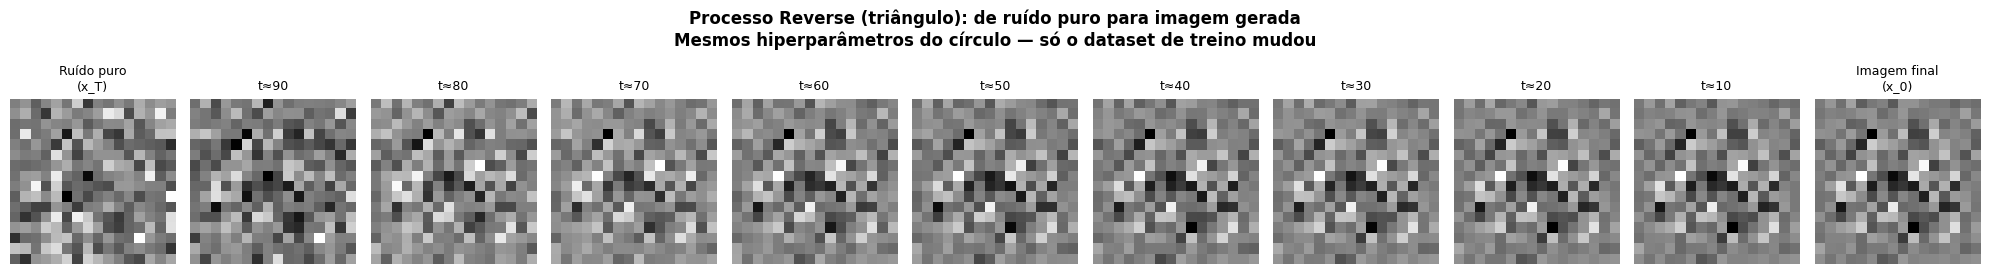

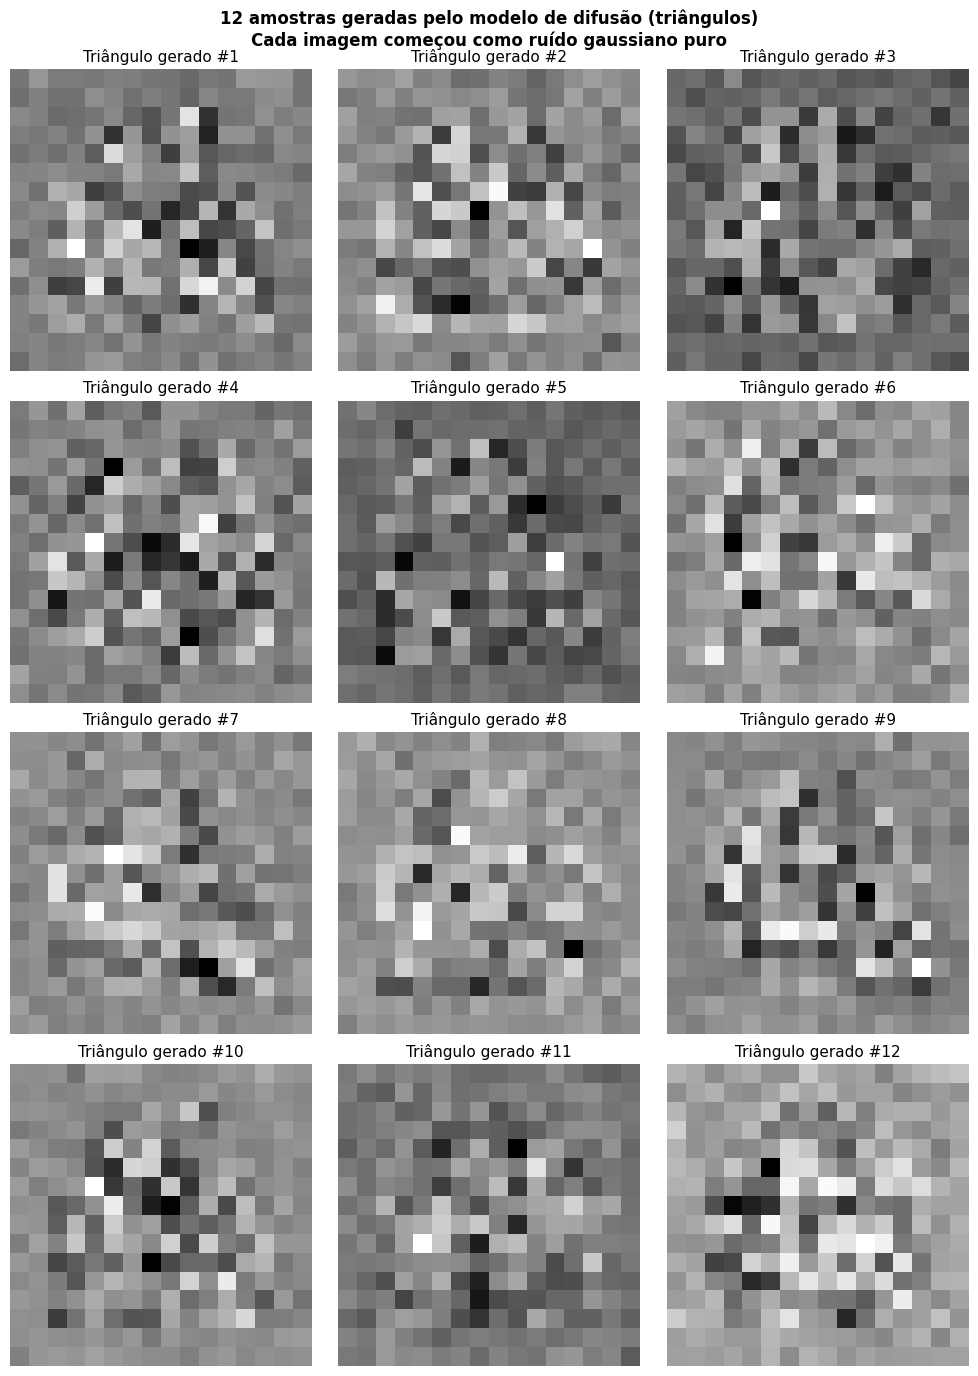

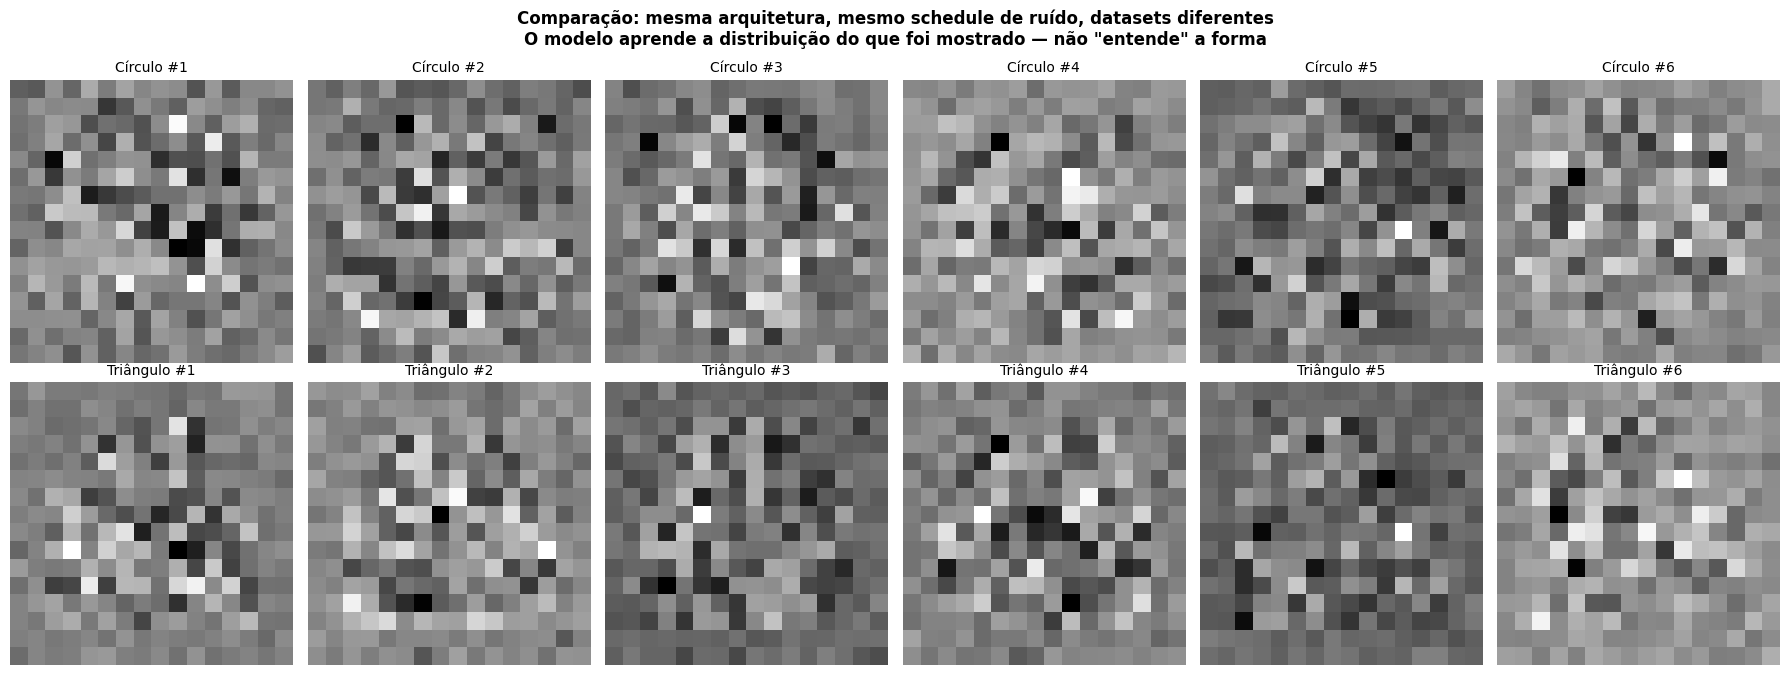


Conclusão:
  denoiser         → treinado em círculos  → gera círculos
  denoiser_triangulo → treinado em triângulos → gera triângulos

A única diferença é o dataset. Arquitetura, loss e schedule são idênticos.
O modelo não tem conceito de "círculo" ou "triângulo" — ele modela distribuições de pixels.


In [27]:
# ============================================================
# Gerar triângulos via processo reverse
# ============================================================

print('Gerando imagens de triângulos via processo reverse...')

imagens_geradas_triangulo = []
for s in range(12):
    img, _ = gerar_imagem_diff(denoiser_triangulo, T=T_DIFF, betas=betas, alphas=alphas,
                                alphas_barra=alphas_barra, img_size=TAMANHO_DIFF, seed=s)
    imagens_geradas_triangulo.append(img)

print(f'Geradas {len(imagens_geradas_triangulo)} imagens')

# Visualizar trajetória da primeira imagem gerada
_, trajetoria_tri = gerar_imagem_diff(denoiser_triangulo, T=T_DIFF, betas=betas, alphas=alphas,
                                       alphas_barra=alphas_barra, img_size=TAMANHO_DIFF, seed=3)

fig, axes = plt.subplots(1, len(trajetoria_tri), figsize=(20, 3))
for i, (ax, frame) in enumerate(zip(axes, trajetoria_tri)):
    ax.imshow(frame, cmap='gray')
    if i == 0:
        ax.set_title('Ruído puro\n(x_T)', fontsize=9)
    elif i == len(trajetoria_tri) - 1:
        ax.set_title('Imagem final\n(x_0)', fontsize=9)
    else:
        t_val = T_DIFF - i * 10
        ax.set_title(f't≈{t_val}', fontsize=9)
    ax.axis('off')

plt.suptitle('Processo Reverse (triângulo): de ruído puro para imagem gerada\n'
             'Mesmos hiperparâmetros do círculo — só o dataset de treino mudou',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar as 12 imagens geradas
fig, axes = plt.subplots(4, 3, figsize=(10, 14))
for i, (ax, img) in enumerate(zip(axes.flat, imagens_geradas_triangulo)):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Triângulo gerado #{i+1}', fontsize=11)
    ax.axis('off')

plt.suptitle('12 amostras geradas pelo modelo de difusão (triângulos)\n'
             'Cada imagem começou como ruído gaussiano puro',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparação lado a lado: círculos vs. triângulos gerados
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
for i in range(6):
    axes[0, i].imshow(imagens_geradas_circulo[i], cmap='gray')
    axes[0, i].set_title(f'Círculo #{i+1}', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(imagens_geradas_triangulo[i], cmap='gray')
    axes[1, i].set_title(f'Triângulo #{i+1}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Comparação: mesma arquitetura, mesmo schedule de ruído, datasets diferentes\n'
             'O modelo aprende a distribuição do que foi mostrado — não "entende" a forma',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('Conclusão:')
print('  denoiser         → treinado em círculos  → gera círculos')
print('  denoiser_triangulo → treinado em triângulos → gera triângulos')
print()
print('A única diferença é o dataset. Arquitetura, loss e schedule são idênticos.')
print('O modelo não tem conceito de "círculo" ou "triângulo" — ele modela distribuições de pixels.')

## Parte 10 — A Conexão: Visão e Linguagem São o Mesmo Problema

Chegamos ao ponto central. LLMs e modelos de difusão têm estruturas diferentes, mas são o mesmo problema:

> **Aprender a distribuição estatística de um tipo de dado — e amostrar dessa distribuição.**

Vamos mostrar isso em código e em tabela.


In [28]:
# === Pseudo-código comparativo: LLM vs. Diffusion Model ===

# Este código não executa nada — é documentação executável
# que mostra a estrutura paralela dos dois tipos de modelo

print('=' * 65)
print('ESTRUTURA COMPARATIVA: LLM vs. MODELO DE DIFUSÃO')
print('=' * 65)
print()
print('--- LLM (ex: GPT) ---')
print()
print('  # Dados de entrada')
print('  tokens = tokenizar(texto)  # ["Olá", ",", "mundo"] → [1234, 7, 889]')
print()
print('  # Forward pass')
print('  logits = transformer(tokens)  # shape: (seq_len, vocab_size)')
print()
print('  # Objetivo de treino')
print('  loss = cross_entropy(logits, tokens_deslocados_1)')
print('  # Minimizar: -log P(próximo_token | tokens_anteriores)')
print()
print('  # Geração')
print('  for t in range(comprimento_máximo):')
print('      probs = softmax(transformer(sequencia_atual)[-1])')
print('      novo_token = amostrar(probs)  # 1 token por vez')
print('      sequencia_atual.append(novo_token)')
print()
print('-' * 65)
print()
print('--- MODELO DE DIFUSÃO (ex: Stable Diffusion) ---')
print()
print('  # Dados de entrada')
print('  pixels = preprocessar(imagem)  # array (H, W, 3) → tensor normalizado')
print()
print('  # Processo forward (adição de ruído)')
print('  t = sortear_timestep(0, T)')
print('  epsilon = ruido_gaussiano(mesma_shape_que_pixels)')
print('  x_t = sqrt_ab[t] * pixels + sqrt_1_ab[t] * epsilon')
print()
print('  # Forward pass')
print('  epsilon_pred = unet(x_t, t)  # prever o ruído')
print()
print('  # Objetivo de treino')
print('  loss = mse(epsilon_pred, epsilon)')
print('  # Minimizar: erro de previsão do ruído')
print()
print('  # Geração')
print('  x = ruido_gaussiano(H * W)  # começar com ruído puro')
print('  for t in reversed(range(T)):')
print('      epsilon_pred = unet(x, t)  # prever ruído em cada passo')
print('      x = remover_ruido(x, epsilon_pred, t)  # atualizar imagem')
print()
print('=' * 65)


ESTRUTURA COMPARATIVA: LLM vs. MODELO DE DIFUSÃO

--- LLM (ex: GPT) ---

  # Dados de entrada
  tokens = tokenizar(texto)  # ["Olá", ",", "mundo"] → [1234, 7, 889]

  # Forward pass
  logits = transformer(tokens)  # shape: (seq_len, vocab_size)

  # Objetivo de treino
  loss = cross_entropy(logits, tokens_deslocados_1)
  # Minimizar: -log P(próximo_token | tokens_anteriores)

  # Geração
  for t in range(comprimento_máximo):
      probs = softmax(transformer(sequencia_atual)[-1])
      novo_token = amostrar(probs)  # 1 token por vez
      sequencia_atual.append(novo_token)

-----------------------------------------------------------------

--- MODELO DE DIFUSÃO (ex: Stable Diffusion) ---

  # Dados de entrada
  pixels = preprocessar(imagem)  # array (H, W, 3) → tensor normalizado

  # Processo forward (adição de ruído)
  t = sortear_timestep(0, T)
  epsilon = ruido_gaussiano(mesma_shape_que_pixels)
  x_t = sqrt_ab[t] * pixels + sqrt_1_ab[t] * epsilon

  # Forward pass
  epsilon_pred = 

### Tabela de analogias expandida

| | **LLM (GPT)** | **Modelo de Difusão** |
|---|---|---|
| **Dado** | Sequência de tokens | Imagem (array de pixels) |
| **Objetivo do treino** | Minimizar cross-entropy da predição do próximo token | Minimizar MSE do ruído predito vs. real |
| **O que é "geração"** | Amostragem autoregressiva (1 token por vez) | Amostragem pelo processo reverse (T passos) |
| **Condicionamento** | Prompt textual concatenado ao contexto | Embedding de texto via CLIP (cross-attention na U-Net) |
| **Escala** | Bilhões de tokens de texto da internet | Bilhões de pares (imagem, legenda) |
| **"Compreensão"** | **Não existe** | **Não existe** |
| **"Intenção"** | **Não existe** | **Não existe** |
| **"Consciência"** | **Não existe** | **Não existe** |

---

### Como funciona o condicionamento em texto (DALL-E, Stable Diffusion, Veo)

Nesses modelos, o texto do prompt é:
1. Tokenizado e codificado por um modelo de linguagem (CLIP ou T5)
2. O embedding resultante é injetado na U-Net via **cross-attention**
3. A U-Net aprendeu, durante o treino, que certos padrões de pixels coocorrem com certos padrões textuais

O modelo não "entende" o texto. Ele aprendeu correlações estatísticas entre padrões linguísticos e padrões visuais — porque no corpus de treino, imagens de cães aparecem com textos que contêm a palavra "cão".

**Resultado:** quando o prompt contém "cão", o modelo gera pixels que correlacionam estatisticamente com pixels que apareceram em imagens rotuladas com "cão" por humanos.


## Parte 11 — Conclusão

### O que Veo, DALL-E e Stable Diffusion fazem operacionalmente

**1. Aprenderam a distribuição de pixels**

Esses modelos foram treinados em bilhões de imagens. Em cada etapa de treino, pegam uma imagem real, adicionam ruído, e pedem ao modelo para prever esse ruído. Após centenas de bilhões de exemplos, o modelo aprende a distribuição estatística de como pixels se organizam — quais padrões de números costumam aparecer juntos em imagens de cachorros, paisagens, rostos humanos.

**2. Com condicionamento em texto**

Via CLIP ou embeddings similares, aprenderam a correlação entre padrões linguísticos e padrões visuais. A geração é **amostragem dessa distribuição condicionada** — não criação, não imaginação.

**3. O resultado parece mágico porque a escala é absurda**

Não porque há compreensão.

---

### O limite estrutural

- O modelo não sabe o que é uma "vaca". Sabe que certos padrões de pixels aparecem em imagens rotuladas "vaca" por humanos.
- Pedir para gerar "uma vaca tocando violino sob a chuva" funciona porque cada par de conceitos foi visto em contextos sobrepostos no corpus.
- O modelo **falha previsivelmente** quando combina conceitos que raramente co-ocorreram no corpus de treino.

Exemplos de falhas que fazem sentido sob esta ótica:
- Dificuldade histórica com texto em imagens (caracteres raramente co-ocorrem com imagens fotográficas de forma consistente)
- Erros em relações espaciais incomuns ("uma cadeira sobre uma nuvem" — raramente no treino)
- Dedos extras em mãos (mãos humanas com diferentes números de dedos são estatisticamente ambíguas no corpus)

---

### Revisitando os demos anteriores

| Demo | Modelo | Aprende |
|---|---|---|
| Demo 1 | N-gram / MLP | Distribuição de tokens de texto |
| Demo 2 | RNN / LSTM | Distribuição de tokens com memória de sequência |
| Demo 3 | Transformer | Distribuição de tokens com atenção global |
| **Demo 5** | **CNN + Diffusion** | **Distribuição de pixels / features visuais** |

Em todos os casos: **estimadores de distribuição condicional. Nenhum imagina. Nenhum entende.**


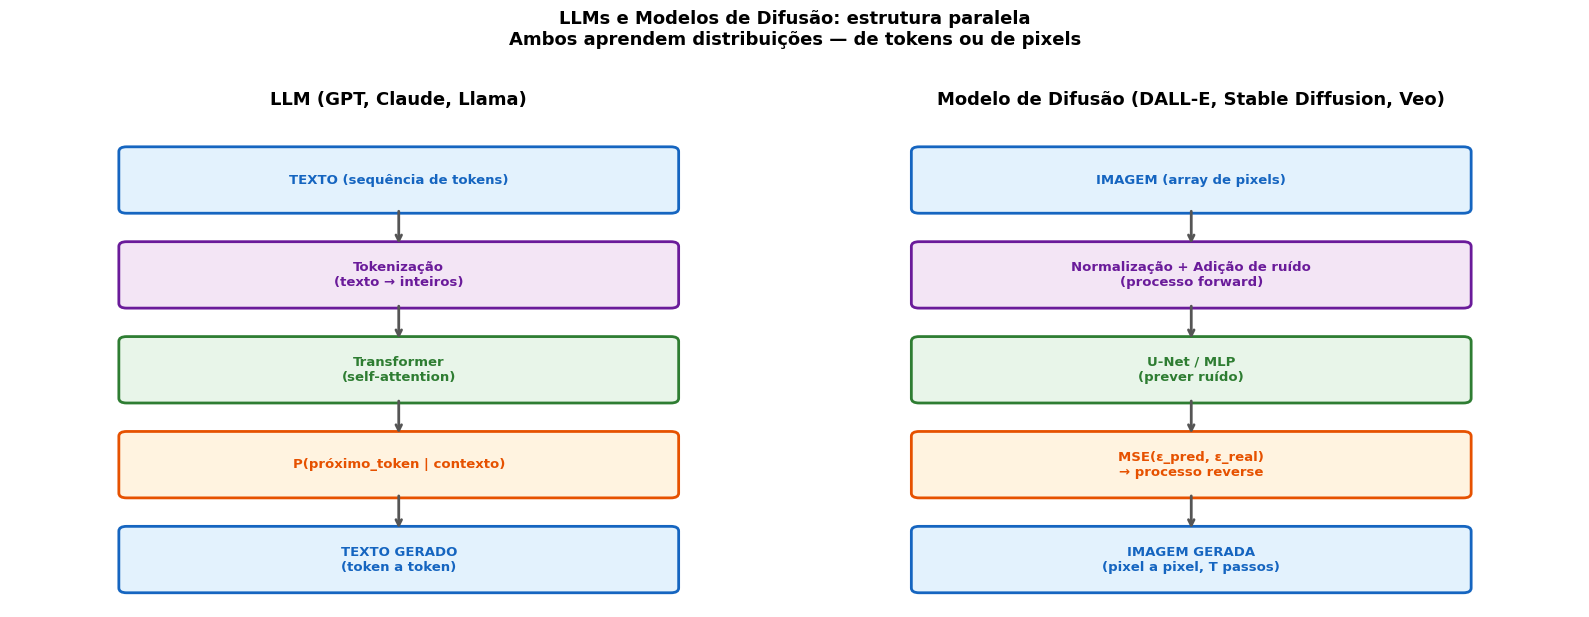

In [31]:
# Visualização final: a analogia estrutural em código

import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Mostrar que tanto LLMs quanto modelos de difusão podem ser descritos
# pela mesma equação: aprender P(saída | entrada)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diagrama 1: LLM
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('LLM (GPT, Claude, Llama)', fontsize=13, fontweight='bold', pad=20)

caixas_llm = [
    (5, 9.0, 'TEXTO (sequência de tokens)', '#E3F2FD', '#1565C0'),
    (5, 7.0, 'Tokenização\n(texto → inteiros)', '#F3E5F5', '#6A1B9A'),
    (5, 5.0, 'Transformer\n(self-attention)', '#E8F5E9', '#2E7D32'),
    (5, 3.0, 'P(próximo_token | contexto)', '#FFF3E0', '#E65100'),
    (5, 1.0, 'TEXTO GERADO\n(token a token)', '#E3F2FD', '#1565C0'),
]

for x, y, texto, cor_fundo, cor_borda in caixas_llm:
    ax.add_patch(mpatches.FancyBboxPatch((x-3.5, y-0.6), 7, 1.2,
                                     boxstyle='round,pad=0.1',
                                     facecolor=cor_fundo, edgecolor=cor_borda, linewidth=2))
    ax.text(x, y, texto, ha='center', va='center', fontsize=9.5, fontweight='bold', color=cor_borda)

for i in range(len(caixas_llm) - 1):
    y_ini = caixas_llm[i][1] - 0.6
    y_fim = caixas_llm[i+1][1] + 0.6
    ax.annotate('', xy=(5, y_fim), xytext=(5, y_ini),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

# Diagrama 2: Diffusion
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Modelo de Difusão (DALL-E, Stable Diffusion, Veo)', fontsize=13, fontweight='bold', pad=20)

caixas_diff = [
    (5, 9.0, 'IMAGEM (array de pixels)', '#E3F2FD', '#1565C0'),
    (5, 7.0, 'Normalização + Adição de ruído\n(processo forward)', '#F3E5F5', '#6A1B9A'),
    (5, 5.0, 'U-Net / MLP\n(prever ruído)', '#E8F5E9', '#2E7D32'),
    (5, 3.0, 'MSE(ε_pred, ε_real)\n→ processo reverse', '#FFF3E0', '#E65100'),
    (5, 1.0, 'IMAGEM GERADA\n(pixel a pixel, T passos)', '#E3F2FD', '#1565C0'),
]

for x, y, texto, cor_fundo, cor_borda in caixas_diff:
    ax.add_patch(mpatches.FancyBboxPatch((x-3.5, y-0.6), 7, 1.2,
                                     boxstyle='round,pad=0.1',
                                     facecolor=cor_fundo, edgecolor=cor_borda, linewidth=2))
    ax.text(x, y, texto, ha='center', va='center', fontsize=9.5, fontweight='bold', color=cor_borda)

for i in range(len(caixas_diff) - 1):
    y_ini = caixas_diff[i][1] - 0.6
    y_fim = caixas_diff[i+1][1] + 0.6
    ax.annotate('', xy=(5, y_fim), xytext=(5, y_ini),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

plt.suptitle('LLMs e Modelos de Difusão: estrutura paralela\nAmbos aprendem distribuições — de tokens ou de pixels',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [32]:
# Resumo final: o que cada modelo faz

print('=' * 70)
print('RESUMO: O QUE CADA MODELO REALMENTE FAZ')
print('=' * 70)
print()
print('Demo 1 — Modelo n-gram / MLP:')
print('  Aprende: P(token_t | token_{t-1}, ..., token_{t-n})')
print('  Mecanismo: tabela de frequências ou multiplicação de matrizes')
print()
print('Demo 2 — RNN / LSTM:')
print('  Aprende: P(token_t | h_{t-1})  onde h é estado oculto acumulado')
print('  Mecanismo: estado oculto comprime o histórico')
print()
print('Demo 3 — Transformer:')
print('  Aprende: P(token_t | token_1, ..., token_{t-1})  com atenção global')
print('  Mecanismo: self-attention permite cada token ver todos os anteriores')
print()
print('Demo 5 — CNN:')
print('  Aprende: P(classe | pixels)  — classificação')
print('  Mecanismo: filtros convolucionais extraem features hierárquicos')
print()
print('Demo 5 — Diffusion:')
print('  Aprende: P(x_0 | ruído, distribuição de treino)')
print('  Mecanismo: treina denoiser, gera via processo reverse iterativo')
print()
print('DALL-E / Stable Diffusion / Veo:')
print('  Aprende: P(pixels | texto)  — difusão condicionada em linguagem')
print('  Mecanismo: igual ao acima, mas com condicionamento via embeddings de texto')
print()
print('=' * 70)
print()
print('Nenhum desses modelos:')
print('  - Entende o que está gerando')
print('  - Tem intenção ou objetivo próprio')
print('  - "Imagina" ou "cria" no sentido humano')
print('  - Raciocina sobre o mundo')
print()
print('Todos esses modelos:')
print('  - Aprendem distribuições estatísticas de dados')
print('  - Amostram dessas distribuições de forma condicionada')
print('  - Produzem resultados que parecem inteligentes porque')
print('    foram treinados em dados produzidos por humanos inteligentes')
print()
print('=' * 70)


RESUMO: O QUE CADA MODELO REALMENTE FAZ

Demo 1 — Modelo n-gram / MLP:
  Aprende: P(token_t | token_{t-1}, ..., token_{t-n})
  Mecanismo: tabela de frequências ou multiplicação de matrizes

Demo 2 — RNN / LSTM:
  Aprende: P(token_t | h_{t-1})  onde h é estado oculto acumulado
  Mecanismo: estado oculto comprime o histórico

Demo 3 — Transformer:
  Aprende: P(token_t | token_1, ..., token_{t-1})  com atenção global
  Mecanismo: self-attention permite cada token ver todos os anteriores

Demo 5 — CNN:
  Aprende: P(classe | pixels)  — classificação
  Mecanismo: filtros convolucionais extraem features hierárquicos

Demo 5 — Diffusion:
  Aprende: P(x_0 | ruído, distribuição de treino)
  Mecanismo: treina denoiser, gera via processo reverse iterativo

DALL-E / Stable Diffusion / Veo:
  Aprende: P(pixels | texto)  — difusão condicionada em linguagem
  Mecanismo: igual ao acima, mas com condicionamento via embeddings de texto


Nenhum desses modelos:
  - Entende o que está gerando
  - Tem inten

---

## Conceito Final

> **Veo não imagina um vídeo. Ele aprendeu a distribuição estatística de como pixels se movem ao longo do tempo condicionados em linguagem — e amostra dessa distribuição. O resultado parece mágico porque a escala é absurda. O mecanismo é o mesmo do demo1.**

---

### O que este notebook demonstrou

1. **Imagens são matrizes de números** — não há círculo, há inteiros entre 0 e 255 organizados em padrões

2. **Convolução é a operação fundamental** — os filtros Sobel do Photoshop e os layers de uma CNN são idênticos; a diferença é que a CNN aprende os coeficientes

3. **CNNs aprendem correlações, não conceitos** — a rede nunca recebeu a definição de "círculo"; aprendeu que certos padrões de ativação correlacionam com a label 0

4. **Difusão é aprendizado de distribuição, não imaginação** — o modelo aprende uma única tarefa (prever ruído) e a geração emerge da inversão desse processo

5. **LLMs e modelos de visão são estruturalmente idênticos** — ambos são estimadores de distribuição condicional; a diferença é apenas o tipo de dado (tokens vs. pixels)

---